# 📋 README — Amazon Electronics Sentiment Classification

---

## Project Overview

This notebook implements a **multi-class sentiment classification system** for Amazon Electronics product reviews. It compares three traditional ML baselines (Logistic Regression, Multinomial Naive Bayes, Linear SVM) against two deep learning architectures (Bi-LSTM with Self-Attention, Transformer Encoder) to classify reviews as **Positive**, **Neutral**, or **Negative**.

## Dataset

| Property | Value |
| --- | --- |
| **Source** | [McAuley-Lab/Amazon-Reviews-2023](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) (HuggingFace) |
| **Category** | Electronics |
| **Sampled** | 50,000 reviews (streamed from full corpus) |
| **After Cleaning** | 47,444 reviews (duplicates removed) |
| **Classes** | Positive (~80%), Negative (~13%), Neutral (~7%) |
| **Split** | 70% Train / 15% Validation / 15% Test (stratified) |

## How to Run

### Environment

- **Platform:** Azure Machine Learning Compute Instance
- **Kernel:** Python 3.10 — AzureML
- **GPU:** CUDA-enabled GPU recommended (training will use CPU if unavailable)

### Instructions

1. Upload `AIDL_Individual.ipynb` to your Azure ML workspace.
2. Open the notebook and select the **Python 3.10 - AzureML** kernel.
3. Click **Run All** (⏩) — the notebook is fully self-contained:
   - All dependencies are installed in the first code cell (`pip install`).
   - The dataset is streamed directly from HuggingFace (no manual download required).
   - Pre-trained GloVe embeddings are downloaded automatically.
   - All random seeds are fixed (`RANDOM_SEED = 42`) for full reproducibility.
4. **Expected runtime:** ~10-5 minutes on a GPU instance (varies by hardware).
5. Output files (`*.png` charts) are saved to the working directory.

### Notebook Structure

| Section | Cells | Description |
| --- | --- | --- |
| **Data Preprocessing & EDA** | 0–30 | Data loading, cleaning, class mapping, visualisation, train/val/test split |
| **ML Baselines (Step 2)** | 31–42 | TF-IDF + Logistic Regression, Naive Bayes, Linear SVM |
| **Bi-LSTM (Step 3A)** | 43–61 | Vocabulary, GloVe embeddings, model architecture, training |
| **Transformer (Step 3B)** | 62–75 | Encoder-only Transformer, training, architecture comparison |
| **Evaluation (Step 4)** | 76–92 | Test-set metrics, confusion matrices, ROC/AUC, per-class accuracy, attention heatmaps |
| **Runtime** | 93–94 | Total notebook execution time |

---


In [2]:
# ============================================================================
# Notebook Runtime Tracker — START
# ============================================================================
import time as _time
_notebook_start_time = _time.time()
print(f'⏱️  Notebook execution started at: {_time.strftime("%Y-%m-%d %H:%M:%S")}')


⏱️  Notebook execution started at: 2026-05-02 16:57:37


# Amazon Electronics Reviews Dataset

This dataset contains **customer reviews from Amazon Electronics products**.

Each record includes:

- the review text
- the rating given by the user
- product identifiers
- metadata about the review

Because the full dataset contains **millions of reviews**, we will **stream the dataset and sample a subset**.

This allows us to:

- avoid downloading massive files
- work with a manageable dataset
- run experiments efficiently

---

## What the next cell does

The code below will:

1. Stream the Amazon Electronics dataset
2. Extract **50,000 reviews**
3. Convert the data to a **Pandas DataFrame**
4. Allow you to inspect the columns and structure

In [3]:
import itertools
from datasets import load_dataset, Dataset

REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"
ds_iter = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)

# Loading a subset of 50,000 English reviews for the assessment
sample = list(itertools.islice(ds_iter, 50000))  # Adjust sample size as needed
dataset = Dataset.from_list(sample)

# Convert to dataset to pandas Dataframe
df = dataset.to_pandas()
print(f"Working dataset size: {len(df):,} reviews")

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working dataset size: 50,000 reviews


In [4]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


---

# Data Dictionary

---

#  Amazon Electronics Reviews Dataset Data Dictionary

This dataset contains **customer reviews of electronics products on Amazon**.

Each row corresponds to **one review**.

| Feature           | Description                       |
| ----------------- | --------------------------------- |
| images            | List of URLs posted with the review          |
| user_id           | Anonymous Reviewer Identifier     |
| asin              | Amazon Standard Product identifier number    |
| parent_asin       | Parent product ID (group variants)           |
| rating            | Star rating (1–5)                 |
| title             | Review title/customer headline    |
| text              | Full customer review text         |
| timestamp         | Time when the review was posted (miliseconds)|
| verified_purchase | Whether the purchase was verified |
| helpful_vote      | Number of helpful votes received  |

---

### Rating Interpretation

| Rating | Meaning         |
| ------ | --------------- |
| 1–2    | Negative review |
| 3      | Neutral review  |
| 4–5    | Positive review |

In many sentiment analysis tasks this is simplified to:

```
1–2 → Negative
4–5 → Positive
```

---


---

#  Problem Formulation

## Business Problem

E-commerce platforms like Amazon generate **millions of unstructured customer reviews** daily. Manually analysing this volume of text to gauge product quality and customer satisfaction is infeasible. Businesses need an **automated, scalable system** to classify review sentiment in real time, enabling:

- **Product quality monitoring**: Flagging products with rising negative sentiment before they damage brand reputation.
- **Customer experience tracking**: Identifying systemic issues (e.g., delivery, defects) across product categories.
- **Data-driven decision making**: Providing actionable intelligence to product managers, marketing teams, and supply chain operations.

## Technical Problem

Given a customer review text $x_i$, predict the sentiment label:

$$y_i \in \{\text{Negative (0)},\ \text{Neutral (1)},\ \text{Positive (2)}\}$$

This is a **multi-class text classification task**. Star ratings (1–5) serve as proxy labels:

| Rating | Sentiment | Label |
|--------|-----------|-------|
| 1–2    | Negative  | 0     |
| 3      | Neutral   | 1     |
| 4–5    | Positive  | 2     |

## Real-World Relevance

Amazon processes **hundreds of millions of reviews** across its marketplace. Automated sentiment classification systems underpin:

- **Recommendation engines** that surface well-reviewed products
- **Seller performance dashboards** for marketplace quality control
- **Consumer trust signals** (star ratings, sentiment summaries)
- **Competitive intelligence** for brands monitoring customer perception

This project develops a deep learning solution for this task, comparing it against traditional ML baselines to evaluate when the added complexity of neural architectures is justified.

---


---

#  Data Preprocessing & Exploratory Data Analysis

This step prepares the raw Amazon Electronics reviews for modelling. We will:

1. Inspect the raw data and handle complex data types (dictionaries, lists)
2. Remove missing values and duplicates
3. Map star ratings to sentiment labels
4. Clean and preprocess review text
5. Explore the data through visualisations
6. Address class imbalance
7. Create stratified train/validation/test splits
8. Build a PyTorch data pipeline

---

## Imports & Configuration

In [5]:
# ============================================================================
# Library Imports & Global Configuration
# ============================================================================
# Core data handling
import pandas as pd
import numpy as np
import re
from collections import Counter

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Visualisation defaults ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device:      {torch.cuda.get_device_name(0)}')

PyTorch version: 2.9.1+cu128
CUDA available:  True
GPU device:      Tesla T4


### Initial Data Inspection

Before any cleaning, we inspect the raw dataset to understand its structure, data types, and identify columns that contain complex types (e.g., dictionaries or lists) which need special handling.

In [6]:
# ============================================================================
# Initial Data Inspection
# ============================================================================
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Summary Statistics for Numeric Columns ===')
df.describe()

=== Dataset Shape ===
Rows: 50,000  |  Columns: 10

=== Data Types ===
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

=== Summary Statistics for Numeric Columns ===


,rating,timestamp,helpful_vote
count,50000.000000,5.000000e+04,50000.000000
mean,4.257320,1.545335e+12,1.383800
std,1.255475,9.535194e+10,10.853546
min,1.000000,9.709285e+11,0.000000
25%,4.000000,1.484573e+12,0.000000
50%,5.000000,1.566703e+12,0.000000
75%,5.000000,1.617917e+12,1.000000
max,5.000000,1.679107e+12,940.000000


### Dictionary & Complex Type Handling

The `images` column contains **lists of dictionaries** (image metadata uploaded by reviewers). Since we are performing **text-based** sentiment classification, image data is not relevant and will be dropped alongside other non-text columns (`user_id`, `asin`, `parent_asin`, `timestamp`) to keep our pipeline focused and memory-efficient.

In [7]:
# ============================================================================
# Handle Complex Types & Select Relevant Columns
# ============================================================================

# Inspect the 'images' column — typically contains lists of dicts
print('=== Inspecting complex columns ===')
print(f"Type of 'images' entries: {type(df['images'].iloc[0])}")

non_empty_images = df[df['images'].apply(
    lambda x: len(x) > 0 if isinstance(x, (list, dict)) else False
)]
print(f'Reviews with images: {len(non_empty_images):,} '
      f'({len(non_empty_images) / len(df) * 100:.1f}%)')

if len(non_empty_images) > 0:
    print(f'\nExample images entry:\n{non_empty_images["images"].iloc[0]}')

# ── Select only sentiment-relevant columns ────────────────────────────────
RELEVANT_COLUMNS = ['rating', 'title', 'text', 'verified_purchase', 'helpful_vote']
columns_to_drop = [c for c in df.columns if c not in RELEVANT_COLUMNS]

print(f'\n=== Column Selection ===')
print(f'Dropping:   {columns_to_drop}')
print(f'Retaining:  {RELEVANT_COLUMNS}')

df = df[RELEVANT_COLUMNS].copy()
print(f'\nNew shape: {df.shape}')
df.head()

=== Inspecting complex columns ===
Type of 'images' entries: <class 'numpy.ndarray'>
Reviews with images: 0 (0.0%)

=== Column Selection ===
Dropping:   ['images', 'asin', 'parent_asin', 'user_id', 'timestamp']
Retaining:  ['rating', 'title', 'text', 'verified_purchase', 'helpful_vote']

New shape: (50000, 5)


,rating,title,text,verified_purchase,helpful_vote
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,True,0
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,True,0
2,5.0,Excellent!,I love these. They even come with a carry case...,True,0
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,True,18
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,True,0


##  Missing Values & Duplicate Removal

Data quality is critical for model performance. We:
- Report missing values across all columns
- Drop rows where `text` is missing (the review body is essential for classification)
- Fill missing `title` values with empty strings (title is supplementary)
- Remove exact duplicate reviews to prevent data leakage between splits

In [8]:
# ============================================================================
# Missing Values & Duplicate Handling
# ============================================================================

def inspect_missing_values(dataframe):
    """Generate a missing values report for all columns."""
    missing = dataframe.isnull().sum()
    missing_pct = (missing / len(dataframe) * 100).round(2)
    report = pd.DataFrame({
        'Missing Count': missing,
        'Missing (%)': missing_pct
    })
    print('=== Missing Values Report ===')
    print(report)
    return report


def handle_missing_and_duplicates(dataframe):
    """
    Clean the dataset by addressing missing values and duplicates.

    Strategy:
        - Drop rows with missing 'text' (essential for classification)
        - Fill missing 'title' with empty string (supplementary field)
        - Remove exact duplicates on ('text', 'rating') to avoid data leakage
    """
    initial_size = len(dataframe)

    # Drop rows where the review body is missing
    dataframe = dataframe.dropna(subset=['text'])
    after_na = len(dataframe)
    print(f'Dropped {initial_size - after_na:,} rows with missing "text"')

    # Fill missing titles with empty string (title is supplementary context)
    dataframe['title'] = dataframe['title'].fillna('')

    # Remove exact duplicate reviews (same text + same rating)
    dataframe = dataframe.drop_duplicates(subset=['text', 'rating'], keep='first')
    after_dedup = len(dataframe)
    print(f'Dropped {after_na - after_dedup:,} duplicate reviews')

    print(f'\nDataset: {initial_size:,} → {after_dedup:,} '
          f'({initial_size - after_dedup:,} rows removed)')
    return dataframe


# Execute
missing_report = inspect_missing_values(df)
df = handle_missing_and_duplicates(df)
print(f'\nFinal shape: {df.shape}')

=== Missing Values Report ===
                   Missing Count  Missing (%)
rating                         0          0.0
title                          0          0.0
text                           0          0.0
verified_purchase              0          0.0
helpful_vote                   0          0.0
Dropped 0 rows with missing "text"
Dropped 2,556 duplicate reviews

Dataset: 50,000 → 47,444 (2,556 rows removed)

Final shape: (47444, 5)


## Sentiment Label Mapping

We convert the 5-point star rating to a **3-class sentiment label** following standard NLP convention:

| Stars | Sentiment | Numeric Label |
|-------|-----------|---------------|
| 1–2   | Negative  | 0             |
| 3     | Neutral   | 1             |
| 4–5   | Positive  | 2             |

This mapping balances **granularity** (distinguishing mixed opinions) with **practicality** (sufficient samples per class for model training).

In [9]:
# ============================================================================
# Sentiment Label Mapping
# ============================================================================

def map_sentiment_labels(dataframe, rating_col='rating'):
    """
    Map star ratings to 3-class sentiment labels.

    Mapping:
        1-2 stars → 0 (Negative)
        3 stars   → 1 (Neutral)
        4-5 stars → 2 (Positive)

    Returns:
        DataFrame with 'sentiment' (int) and 'sentiment_label' (str) columns.
    """
    SENTIMENT_MAP = {1: 0, 2: 0, 3: 1, 4: 2, 5: 2}
    LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    dataframe['sentiment'] = dataframe[rating_col].map(SENTIMENT_MAP)
    dataframe['sentiment_label'] = dataframe['sentiment'].map(LABEL_NAMES)

    # Print mapping and distribution
    print('=== Sentiment Label Mapping ===')
    for rating, sentiment in sorted(SENTIMENT_MAP.items()):
        print(f'  {rating} star → {LABEL_NAMES[sentiment]} ({sentiment})')

    print(f'\n=== Class Distribution ===')
    dist = dataframe['sentiment_label'].value_counts()
    for label in ['Negative', 'Neutral', 'Positive']:
        count = dist.get(label, 0)
        print(f'  {label:>8}: {count:>8,} ({count / len(dataframe) * 100:.1f}%)')

    return dataframe


df = map_sentiment_labels(df)
df[['rating', 'sentiment', 'sentiment_label']].head(10)

=== Sentiment Label Mapping ===
  1 star → Negative (0)
  2 star → Negative (0)
  3 star → Neutral (1)
  4 star → Positive (2)
  5 star → Positive (2)

=== Class Distribution ===
  Negative:    6,212 (13.1%)
   Neutral:    3,382 (7.1%)
  Positive:   37,850 (79.8%)


,rating,sentiment,sentiment_label
0,3.0,1,Neutral
1,1.0,0,Negative
2,5.0,2,Positive
3,5.0,2,Positive
4,5.0,2,Positive
5,5.0,2,Positive
6,5.0,2,Positive
7,5.0,2,Positive
8,5.0,2,Positive
9,5.0,2,Positive


## Text Preprocessing

We apply **targeted cleaning** to the review text:

1. **Lowercase** — normalise case
2. **Remove HTML tags** — artefacts from web scraping
3. **Remove URLs** — not semantically useful for sentiment
4. **Keep sentiment-bearing punctuation** — `!` and `?` carry strong sentiment signals (e.g., "terrible!!!")
5. **Normalise whitespace** — clean formatting
6. **Concatenate title + text** — review titles often contain concentrated sentiment (e.g., "Waste of money")

> **Design Decision**: We intentionally **do not** apply stemming or lemmatisation. The Bi-LSTM architecture will learn contextual word representations directly, and aggressive preprocessing can destroy useful morphological information (e.g., "disappointing" vs "disappointed" carry different nuances).

In [10]:
# ============================================================================
# Text Preprocessing
# ============================================================================

def clean_text(text):
    """
    Clean a single review text string.

    Steps:
        1. Lowercase all characters
        2. Remove HTML tags (e.g., <br>, <p>)
        3. Remove URLs
        4. Keep letters, digits, and sentiment-bearing punctuation (! ? . , ')
        5. Normalise whitespace

    Note:
        We preserve '!' and '?' as they are strong sentiment indicators.
        We do NOT stem or lemmatise — the Bi-LSTM learns contextual
        representations and benefits from full word forms.
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)              # Strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)     # Strip URLs
    text = re.sub(r"[^a-z0-9\s!?.,\'\-]", '', text) # Keep basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # Normalise whitespace
    return text


def preprocess_reviews(dataframe):
    """
    Apply text cleaning and create the combined 'review' field.

    Combining title + text provides richer context for the model,
    as review titles often contain strong, concentrated sentiment
    indicators (e.g., 'Waste of money', 'Absolutely love it!').

    Returns:
        DataFrame with added 'review' (cleaned) and 'word_count' columns.
    """
    print('=== Text Preprocessing ===')

    # Clean both fields
    dataframe['clean_title'] = dataframe['title'].apply(clean_text)
    dataframe['clean_text'] = dataframe['text'].apply(clean_text)

    # Combine title + text into a single review field
    dataframe['review'] = (
        dataframe['clean_title'] + ' ' + dataframe['clean_text']
    ).str.strip()

    # Remove reviews that are empty after cleaning
    empty_mask = dataframe['review'].str.len() == 0
    empty_count = empty_mask.sum()
    if empty_count > 0:
        dataframe = dataframe[~empty_mask].copy()
        print(f'  Removed {empty_count} empty reviews after cleaning')

    # Calculate word count for analysis
    dataframe['word_count'] = dataframe['review'].apply(lambda x: len(x.split()))

    print(f'  Processed: {len(dataframe):,} reviews')
    print(f'  Avg word count: {dataframe["word_count"].mean():.1f}')
    print(f'  Median word count: {dataframe["word_count"].median():.1f}')

    # Show a before/after example
    idx = dataframe.index[0]
    print(f'\n=== Example: Before vs After ===')
    print(f'  Original title: {dataframe.loc[idx, "title"]}')
    print(f'  Original text:  {dataframe.loc[idx, "text"][:120]}...')
    print(f'  Cleaned review: {dataframe.loc[idx, "review"][:120]}...')

    return dataframe


df = preprocess_reviews(df)
df[['review', 'sentiment_label', 'word_count']].head()

=== Text Preprocessing ===
  Removed 19 empty reviews after cleaning
  Processed: 47,425 reviews
  Avg word count: 74.7
  Median word count: 41.0

=== Example: Before vs After ===
  Original title: Smells like gasoline! Going back!
  Original text:  First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will ...
  Cleaned review: smells like gasoline! going back! first most offensive they reek of gasoline so if you are sensitiveallergic to petroleu...


,review,sentiment_label,word_count
0,smells like gasoline! going back! first most o...,Neutral,275
1,didnt work at all lenses loosebroken. these di...,Negative,51
2,excellent! i love these. they even come with a...,Positive,95
3,great laptop backpack! i was searching for a s...,Positive,206
4,best headphones in the fifties price range! i'...,Positive,51


## Exploratory Data Analysis

We visualise the dataset to understand:
- **Class distribution**: How imbalanced are the sentiment classes?
- **Review length**: Do negative, neutral, and positive reviews differ in length?
- **Rating distribution**: The underlying star ratings before grouping

These insights directly inform our modelling decisions (class weighting, sequence padding, etc.).

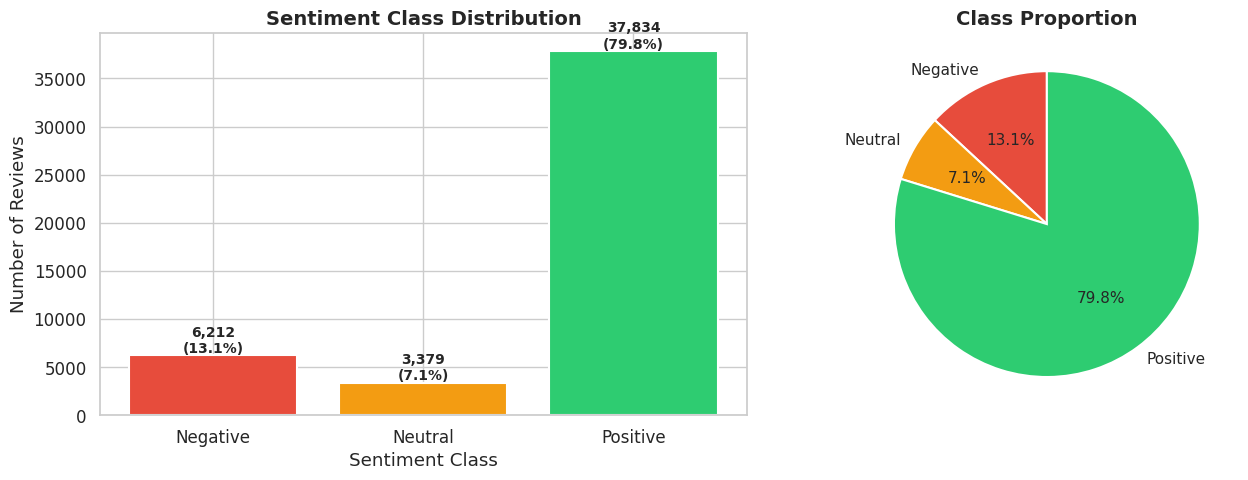


⚠️  Imbalance ratio (majority : minority) = 11.2 : 1
This significant imbalance must be addressed to prevent the model
from defaulting to predicting the majority class (Positive).


In [11]:
# ============================================================================
# Sentiment Class Distribution
# ============================================================================

def plot_class_distribution(dataframe):
    """
    Visualise sentiment class distribution with bar chart and pie chart.
    Highlights the class imbalance problem that must be addressed.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    counts = dataframe['sentiment_label'].value_counts()
    order = ['Negative', 'Neutral', 'Positive']
    colors = ['#e74c3c', '#f39c12', '#2ecc71']  # Red, Amber, Green

    # ── Bar chart with counts and percentages ──
    ax = axes[0]
    values = [counts.get(l, 0) for l in order]
    bars = ax.bar(order, values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Sentiment Class')
    ax.set_ylabel('Number of Reviews')

    for bar, label in zip(bars, order):
        count = counts.get(label, 0)
        pct = count / len(dataframe) * 100
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    # ── Pie chart ──
    ax2 = axes[1]
    ax2.pie(values, labels=order, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax2.set_title('Class Proportion', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Report imbalance ratio
    majority = counts.max()
    minority = counts.min()
    print(f'\n⚠️  Imbalance ratio (majority : minority) = {majority / minority:.1f} : 1')
    print('This significant imbalance must be addressed to prevent the model')
    print('from defaulting to predicting the majority class (Positive).')


plot_class_distribution(df)

/tmp/ipykernel_3585/4132359963.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataframe, x='sentiment_label', y='word_count',


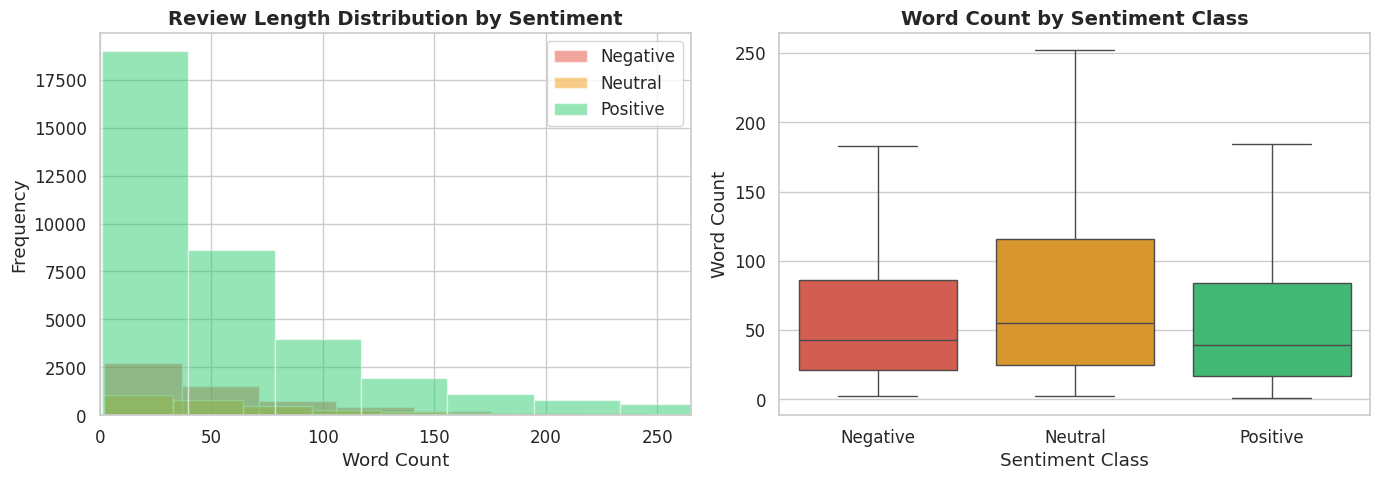


=== Word Count Statistics by Sentiment ===
                 Mean  Median  Std Dev  Min     Max
sentiment_label                                    
Negative         72.8    43.0     95.1  2.0  1736.0
Neutral          97.5    55.0    125.1  2.0  1552.0
Positive         73.0    39.0    104.4  1.0  1936.0


In [12]:
# ============================================================================
# Review Length Analysis
# ============================================================================

def plot_review_length_analysis(dataframe):
    """
    Analyse review length distributions across sentiment classes.

    Understanding length distributions helps inform:
    - Maximum sequence length for padding/truncation
    - Whether review length itself is a discriminative feature
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = {'Negative': '#e74c3c', 'Neutral': '#f39c12', 'Positive': '#2ecc71'}
    order = ['Negative', 'Neutral', 'Positive']

    # ── Overlaid histograms ──
    ax = axes[0]
    for label in order:
        subset = dataframe[dataframe['sentiment_label'] == label]['word_count']
        ax.hist(subset, bins=50, alpha=0.5, label=label,
                color=colors[label], edgecolor='white')
    ax.set_title('Review Length Distribution by Sentiment',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()
    # Clip x-axis at 95th percentile for readability
    ax.set_xlim(0, dataframe['word_count'].quantile(0.95))

    # ── Box plots ──
    ax2 = axes[1]
    sns.boxplot(data=dataframe, x='sentiment_label', y='word_count',
                order=order, palette=colors, ax=ax2, showfliers=False)
    ax2.set_title('Word Count by Sentiment Class',
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Sentiment Class')
    ax2.set_ylabel('Word Count')

    plt.tight_layout()
    plt.show()

    # ── Summary statistics table ──
    print('\n=== Word Count Statistics by Sentiment ===')
    stats = dataframe.groupby('sentiment_label')['word_count'].describe()
    stats = stats[['mean', '50%', 'std', 'min', 'max']]
    stats.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
    print(stats.round(1).to_string())


plot_review_length_analysis(df)

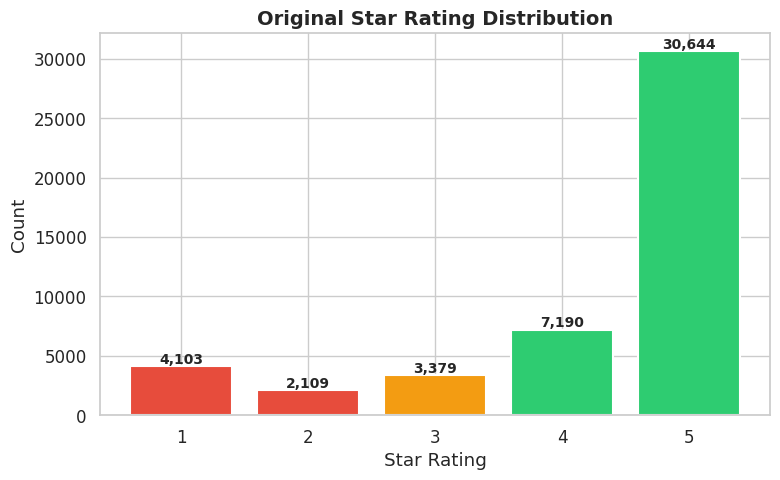

Observation: Amazon reviews are heavily skewed towards 5-star ratings.
This is a well-documented phenomenon in e-commerce review data.


In [13]:
# ============================================================================
# Star Rating Distribution (Original Ratings)
# ============================================================================

def plot_rating_distribution(dataframe):
    """Visualise the original 1-5 star rating distribution."""
    fig, ax = plt.subplots(figsize=(8, 5))

    rating_counts = dataframe['rating'].value_counts().sort_index()
    # Colour-code by sentiment mapping
    bar_colors = ['#e74c3c', '#e74c3c', '#f39c12', '#2ecc71', '#2ecc71']

    bars = ax.bar(rating_counts.index, rating_counts.values,
                  color=bar_colors, edgecolor='white', linewidth=1.5)

    ax.set_title('Original Star Rating Distribution',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Star Rating')
    ax.set_ylabel('Count')
    ax.set_xticks([1, 2, 3, 4, 5])

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print('Observation: Amazon reviews are heavily skewed towards 5-star ratings.')
    print('This is a well-documented phenomenon in e-commerce review data.')


plot_rating_distribution(df)

## Class Imbalance Strategy

As shown in the EDA, Amazon reviews are **heavily skewed towards positive sentiment**. Without intervention, the model would learn to simply predict "Positive" for every input and still achieve high accuracy — a misleading result.

### Strategy: Inverse-Frequency Class Weights

We compute class weights using `sklearn.utils.class_weight.compute_class_weight('balanced', ...)`, which assigns:
- **Higher weights** to minority classes (Negative, Neutral) → penalises misclassification more heavily
- **Lower weights** to the majority class (Positive) → reduces its dominance in the loss function

These weights will be passed to `nn.CrossEntropyLoss(weight=...)` during training.

### Why Weighted Loss over Resampling?

| Approach | Pros | Cons |
|----------|------|------|
| **Weighted Loss** ✓ | Preserves original distribution; memory-efficient; standard in DL | Requires careful weight calibration |
| Oversampling (SMOTE) | Balances classes directly | Creates synthetic text (semantically problematic); increases dataset size |
| Undersampling | Simple to implement | Discards valuable majority-class data |


In [14]:
# ============================================================================
# Compute Class Weights for Imbalanced Data
# ============================================================================

def compute_sentiment_class_weights(dataframe, label_col='sentiment'):
    """
    Compute inverse-frequency class weights to address class imbalance.

    These weights will be passed to nn.CrossEntropyLoss(weight=...) in
    the training loop, ensuring the model is penalised proportionally
    more for misclassifying minority classes.

    Returns:
        dict: {class_id: weight} mapping
        torch.Tensor: weights as a tensor ready for CrossEntropyLoss
    """
    classes = np.array(sorted(dataframe[label_col].unique()))
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=dataframe[label_col].values
    )

    class_weights = dict(zip(classes.tolist(), weights.tolist()))
    weights_tensor = torch.tensor(weights, dtype=torch.float32)

    label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    print('=== Class Weights (Inverse Frequency) ===')
    for cls, weight in class_weights.items():
        count = (dataframe[label_col] == cls).sum()
        print(f'  {label_names[cls]:>8} (class {cls}): '
              f'weight = {weight:.4f}  (n = {count:,})')

    print(f'\nInterpretation: Higher weight → model penalised more for '
          f'misclassifying that class.')
    print(f'This prevents the model from defaulting to the majority class.')

    return class_weights, weights_tensor


class_weights, class_weights_tensor = compute_sentiment_class_weights(df)
print(f'\nWeights tensor (for nn.CrossEntropyLoss): {class_weights_tensor}')

=== Class Weights (Inverse Frequency) ===
  Negative (class 0): weight = 2.5448  (n = 6,212)
   Neutral (class 1): weight = 4.6784  (n = 3,379)
  Positive (class 2): weight = 0.4178  (n = 37,834)

Interpretation: Higher weight → model penalised more for misclassifying that class.
This prevents the model from defaulting to the majority class.

Weights tensor (for nn.CrossEntropyLoss): tensor([2.5448, 4.6784, 0.4178])


## Stratified Train / Validation / Test Split

We split the data using **stratified sampling** to maintain consistent class ratios across all splits:

| Split      | Ratio | Purpose |
|------------|-------|---------|
| Train      | 70%   | Model parameter learning |
| Validation | 15%   | Hyperparameter tuning & early stopping |
| Test       | 15%   | Final, unbiased performance evaluation |

Stratification is critical with imbalanced data to ensure each split has proportional representation of all classes.

In [15]:
# ============================================================================
# Stratified Train / Validation / Test Split
# ============================================================================

def create_stratified_splits(dataframe, train_ratio=0.70, val_ratio=0.15,
                              test_ratio=0.15, seed=42):
    """
    Create stratified train/validation/test splits.

    Stratification ensures each split maintains the same class distribution
    as the full dataset — critical for imbalanced classification tasks.

    Args:
        dataframe: Input DataFrame with 'sentiment' column.
        train_ratio: Fraction for training (default: 0.70).
        val_ratio: Fraction for validation (default: 0.15).
        test_ratio: Fraction for testing (default: 0.15).
        seed: Random seed for reproducibility.

    Returns:
        Tuple of (train_df, val_df, test_df).
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, \
        'Split ratios must sum to 1.0'

    # First split: train vs (validation + test)
    train_df, temp_df = train_test_split(
        dataframe,
        test_size=(val_ratio + test_ratio),
        stratify=dataframe['sentiment'],
        random_state=seed
    )

    # Second split: validation vs test
    relative_test_ratio = test_ratio / (val_ratio + test_ratio)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_ratio,
        stratify=temp_df['sentiment'],
        random_state=seed
    )

    # Verification table
    print('=== Stratified Data Splits ===')
    print(f'{"Split":<12} {"Size":>8} {"Negative":>10} {"Neutral":>10} {"Positive":>10}')
    print('-' * 55)
    for name, split_df in [('Train', train_df), ('Validation', val_df),
                            ('Test', test_df)]:
        neg = (split_df['sentiment'] == 0).sum()
        neu = (split_df['sentiment'] == 1).sum()
        pos = (split_df['sentiment'] == 2).sum()
        print(f'{name:<12} {len(split_df):>8,} {neg:>10,} {neu:>10,} {pos:>10,}')

    print(f'\n✓ Stratification verified: class ratios are consistent across all splits.')

    return train_df, val_df, test_df


train_df, val_df, test_df = create_stratified_splits(df, seed=RANDOM_SEED)

=== Stratified Data Splits ===
Split            Size   Negative    Neutral   Positive
-------------------------------------------------------
Train          33,197      4,348      2,365     26,484
Validation      7,114        932        507      5,675
Test            7,114        932        507      5,675

✓ Stratification verified: class ratios are consistent across all splits.


## PyTorch Data Pipeline

We build a custom `SentimentDataset` class inheriting from `torch.utils.data.Dataset`. This provides:
- **Lazy loading**: Data is accessed on demand via `__getitem__`, keeping memory usage low
- **Compatibility**: Integrates directly with PyTorch's `DataLoader` for batching and shuffling
- **Modularity**: The dataset class is decoupled from the model, allowing easy experimentation

In [16]:
# ============================================================================
# Custom PyTorch Dataset & DataLoader
# ============================================================================

class SentimentDataset(Dataset):
    """
    Custom PyTorch Dataset for sentiment classification.

    Stores cleaned review texts and their corresponding sentiment labels.
    Designed for lazy loading to minimise memory footprint on Azure VM.

    Tokenisation and numericalization will be integrated in Step 3
    when the vocabulary is built alongside the model architecture.

    Args:
        texts (list[str]): Cleaned review strings.
        labels (list[int]): Sentiment labels (0=Negative, 1=Neutral, 2=Positive).
    """

    def __init__(self, texts, labels):
        assert len(texts) == len(labels), \
            f'Mismatch: {len(texts)} texts vs {len(labels)} labels'
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            'text': self.texts[idx],
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ── Instantiate datasets ──────────────────────────────────────────────────
train_dataset = SentimentDataset(
    texts=train_df['review'].tolist(),
    labels=train_df['sentiment'].tolist()
)
val_dataset = SentimentDataset(
    texts=val_df['review'].tolist(),
    labels=val_df['sentiment'].tolist()
)
test_dataset = SentimentDataset(
    texts=test_df['review'].tolist(),
    labels=test_df['sentiment'].tolist()
)

# ── DataLoader configuration ──────────────────────────────────────────────
BATCH_SIZE = 64  # Balanced for Azure VM memory constraints

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ── Verification ──────────────────────────────────────────────────────────
print('=== DataLoader Configuration ===')
print(f'Batch size:        {BATCH_SIZE}')
print(f'Train batches:     {len(train_loader):,}')
print(f'Validation batches:{len(val_loader):,}')
print(f'Test batches:      {len(test_loader):,}')

# Inspect a sample batch
sample_batch = next(iter(train_loader))
print(f'\n=== Sample Batch ===')
print(f'Text (first item):  \'{sample_batch["text"][0][:80]}...\'') 
print(f'Label (first item): {sample_batch["label"][0].item()}')
print(f'Batch labels shape: {sample_batch["label"].shape}')
print(f'\n✓ Data pipeline is ready.')
print(f'  Tokenisation & numericalization will be added in Step 3 (Model Implementation).')

=== DataLoader Configuration ===
Batch size:        64
Train batches:     519
Validation batches:112
Test batches:      112

=== Sample Batch ===
Text (first item):  'my husband hates my shopping habits!!! honest true like everyone else i check re...'
Label (first item): 0
Batch labels shape: torch.Size([64])

✓ Data pipeline is ready.
  Tokenisation & numericalization will be added in Step 3 (Model Implementation).


---
### Key Findings
- Amazon reviews are **heavily skewed** towards positive sentiment — class weights are essential
- Review lengths vary by sentiment class — this will inform sequence padding
- The data pipeline is modular and ready for the Bi-LSTM architecture



---

# Traditional Machine Learning Baseline (LO1 Support)

## Purpose

Before building a deep learning model, we establish **empirical baselines** using traditional ML classifiers. This serves two critical goals:

1. **Fair Comparison**: Provides concrete performance metrics to compare against the Bi-LSTM, enabling a sophisticated discussion of when DL complexity is justified.
2. **Assessment Requirement (LO1)**: The critical reflection report requires an "in-depth comparison of ML and DL paradigms" — this step generates the data for that analysis.

## Approach

We use **TF-IDF (Term Frequency–Inverse Document Frequency)** as the feature representation, paired with three classifiers:

| Model | Why Include It |
|-------|----------------|
| **Logistic Regression** | Strong linear baseline; fast, interpretable, often surprisingly competitive on text tasks |
| **Multinomial Naive Bayes** | Classic NLP baseline; embodies the "bag-of-words" assumption — good reference point |
| **Linear SVM** | Often the best traditional ML method for text classification; maximises margin between classes |

### Why TF-IDF?

TF-IDF converts raw text into fixed-size numerical vectors by:
- **TF (Term Frequency)**: How often a word appears in a document
- **IDF (Inverse Document Frequency)**: How rare a word is across all documents

Words that are **frequent in one review but rare overall** (e.g., "defective", "outstanding") get high weights — exactly the kind of words that carry sentiment.

### Key Limitation 

TF-IDF treats text as a **bag of words** — it loses all word order and context. "Not good" and "good" contribute equally to the "good" feature. This is precisely the limitation that deep learning architectures (Bi-LSTM, Transformers) address by modelling **sequential context**.

---


## TF-IDF Feature Extraction

In [17]:
# ============================================================================
# TF-IDF Feature Extraction
# ============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer

def build_tfidf_features(train_texts, val_texts, test_texts,
                          max_features=20000, ngram_range=(1, 2)):
    """
    Convert cleaned review text into TF-IDF feature matrices.

    Design Decisions:
        - max_features=20000: Limits vocabulary size to the 20,000 most
          informative terms, balancing expressiveness with computational
          efficiency.
        - ngram_range=(1, 2): Includes both unigrams and bigrams.
          Bigrams capture simple two-word phrases like 'not good' or
          'works great', partially mitigating the bag-of-words limitation.
        - sublinear_tf=True: Applies logarithmic TF scaling (1 + log(tf)),
          which dampens the effect of very frequent words and is standard
          practice for text classification.

    Important: The vectoriser is fit ONLY on training data to prevent
    data leakage. Validation and test sets are transformed using the
    same fitted vocabulary.

    Args:
        train_texts: Training review texts.
        val_texts: Validation review texts.
        test_texts: Test review texts.
        max_features: Maximum vocabulary size.
        ngram_range: Tuple specifying unigram/bigram/trigram range.

    Returns:
        Tuple of (X_train, X_val, X_test, vectoriser).
    """
    vectoriser = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        sublinear_tf=True,          # Logarithmic TF scaling
        strip_accents='unicode',
        dtype=np.float32            # Memory-efficient float type
    )

    # Fit on training data ONLY (prevents data leakage)
    X_train = vectoriser.fit_transform(train_texts)
    X_val = vectoriser.transform(val_texts)
    X_test = vectoriser.transform(test_texts)

    print('=== TF-IDF Vectorisation ===')
    print(f'Vocabulary size:    {len(vectoriser.vocabulary_):,}')
    print(f'N-gram range:       {ngram_range}')
    print(f'Train matrix shape: {X_train.shape} (sparse)')
    print(f'Val matrix shape:   {X_val.shape}')
    print(f'Test matrix shape:  {X_test.shape}')
    print(f'\nMemory (train):     {X_train.data.nbytes / 1e6:.1f} MB (sparse format)')

    return X_train, X_val, X_test, vectoriser


# Extract features
X_train_tfidf, X_val_tfidf, X_test_tfidf, tfidf_vectoriser = build_tfidf_features(
    train_df['review'],
    val_df['review'],
    test_df['review']
)

# Prepare label arrays
y_train = train_df['sentiment'].values
y_val = val_df['sentiment'].values
y_test = test_df['sentiment'].values

=== TF-IDF Vectorisation ===
Vocabulary size:    20,000
N-gram range:       (1, 2)
Train matrix shape: (33197, 20000) (sparse)
Val matrix shape:   (7114, 20000)
Test matrix shape:  (7114, 20000)

Memory (train):     10.4 MB (sparse format)


### Top TF-IDF Features by Sentiment

To build intuition about what the ML models are working with, we inspect the **highest-weighted TF-IDF features** for each sentiment class. This also serves as a sanity check — we expect negative reviews to surface words like "waste", "broken", "return", and positive reviews to contain "excellent", "perfect", "love".

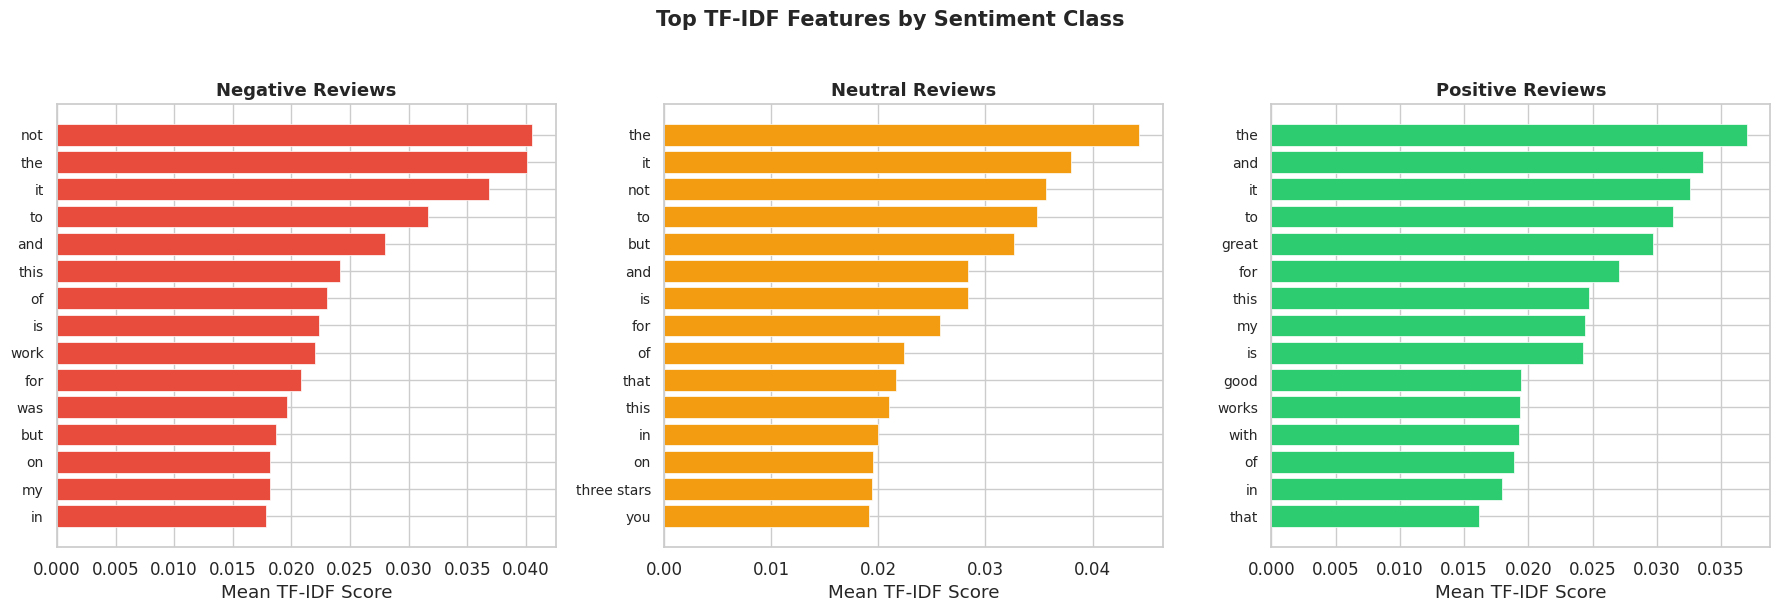

In [18]:
# ============================================================================
# Inspect Top TF-IDF Features per Sentiment Class
# ============================================================================

def show_top_tfidf_features(tfidf_matrix, labels, vectoriser, n_top=15):
    """
    Display the highest-weighted TF-IDF features for each sentiment class.

    Computes the mean TF-IDF weight for each feature within each class,
    then ranks them. This reveals which words are most characteristic
    of each sentiment — a useful sanity check and interpretability aid.
    """
    feature_names = np.array(vectoriser.get_feature_names_out())
    label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    colors = ['#e74c3c', '#f39c12', '#2ecc71']

    for cls, (ax, color) in enumerate(zip(axes, colors)):
        # Mean TF-IDF score per feature for this class
        class_mask = labels == cls
        mean_tfidf = tfidf_matrix[class_mask].mean(axis=0).A1
        top_indices = mean_tfidf.argsort()[-n_top:][::-1]

        top_features = feature_names[top_indices]
        top_scores = mean_tfidf[top_indices]

        ax.barh(range(n_top), top_scores[::-1], color=color,
                edgecolor='white', linewidth=0.5)
        ax.set_yticks(range(n_top))
        ax.set_yticklabels(top_features[::-1], fontsize=10)
        ax.set_title(f'{label_names[cls]} Reviews',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Mean TF-IDF Score')

    plt.suptitle('Top TF-IDF Features by Sentiment Class',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


show_top_tfidf_features(X_train_tfidf, y_train, tfidf_vectoriser)

## Baseline Model Training

We train three traditional ML classifiers, each configured with `class_weight='balanced'` to address the same class imbalance problem identified. 

In [19]:
# ============================================================================
# Train Traditional ML Baseline Models
# ============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import time


def train_baseline_models(X_train, y_train, X_val, y_val, seed=42):
    """
    Train and evaluate three traditional ML classifiers.

    Models:
        1. Logistic Regression — strong linear baseline with class weighting
        2. Multinomial Naive Bayes — probabilistic bag-of-words baseline
        3. Linear SVM — maximum-margin classifier (wrapped for probability
           estimates via CalibratedClassifierCV for later comparison)

    All models use class_weight='balanced' where supported to handle
    the class imbalance consistently with our DL approach.

    Args:
        X_train, y_train: Training features and labels.
        X_val, y_val: Validation features and labels.
        seed: Random seed for reproducibility.

    Returns:
        dict: {model_name: {'model': fitted_model, 'train_time': seconds}}
    """
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            solver='lbfgs',
            random_state=seed,
            n_jobs=-1
        ),
        'Multinomial NB': MultinomialNB(
            alpha=1.0  # Laplace smoothing (NB does not support class_weight;
                       # imbalance is partially handled by TF-IDF weighting)
        ),
        'Linear SVM': CalibratedClassifierCV(
            estimator=LinearSVC(
                class_weight='balanced',
                max_iter=2000,
                random_state=seed
            ),
            cv=3  # 3-fold calibration for probability estimates
        )
    }

    results = {}
    for name, model in models.items():
        print(f'Training {name}...', end=' ')
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        train_acc = model.score(X_train, y_train)
        val_acc = model.score(X_val, y_val)

        results[name] = {
            'model': model,
            'train_time': train_time,
            'train_acc': train_acc,
            'val_acc': val_acc
        }

        print(f'done in {train_time:.1f}s | '
              f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    return results


baseline_results = train_baseline_models(
    X_train_tfidf, y_train,
    X_val_tfidf, y_val,
    seed=RANDOM_SEED
)

Training Logistic Regression... done in 3.4s | Train Acc: 0.9292 | Val Acc: 0.8539
Training Multinomial NB... done in 0.0s | Train Acc: 0.8682 | Val Acc: 0.8568
Training Linear SVM... done in 3.9s | Train Acc: 0.9682 | Val Acc: 0.8961


## Baseline Model Evaluation

We evaluate each model on the **test set** using multiple metrics:

| Metric | Why It Matters |
|--------|----------------|
| **Accuracy** | Overall correctness — but misleading with imbalanced data |
| **Precision** | Of reviews predicted as class X, how many truly are? (Reduces false positives) |
| **Recall** | Of all actual class X reviews, how many did we catch? (Reduces false negatives) |
| **F1 Score** | Harmonic mean of precision and recall — **primary metric** for imbalanced data |
| **Confusion Matrix** | Shows exactly where models confuse classes |

We report both **macro-averaged** (equal weight per class) and **weighted-averaged** (proportional to class size) F1 scores.

In [20]:
# ============================================================================
# Classification Reports (Test Set)
# ============================================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)


def evaluate_baselines_on_test(results, X_test, y_test):
    """
    Generate detailed classification reports for each baseline model
    on the held-out test set.

    Returns:
        dict: {model_name: {'y_pred': predictions, 'report': str, ...}}
    """
    target_names = ['Negative', 'Neutral', 'Positive']
    evaluations = {}

    for name, result in results.items():
        model = result['model']
        y_pred = model.predict(X_test)

        report = classification_report(
            y_test, y_pred,
            target_names=target_names,
            digits=4,
            zero_division=0
        )

        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        evaluations[name] = {
            'y_pred': y_pred,
            'accuracy': acc,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'report': report
        }

        print(f'\n{"=" * 60}')
        print(f' {name} — Test Set Results')
        print(f'{"=" * 60}')
        print(report)

    return evaluations


baseline_evaluations = evaluate_baselines_on_test(
    baseline_results, X_test_tfidf, y_test
)


 Logistic Regression — Test Set Results
              precision    recall  f1-score   support

    Negative     0.6864    0.7704    0.7260       932
     Neutral     0.3321    0.5306    0.4085       507
    Positive     0.9677    0.8966    0.9308      5675

    accuracy                         0.8539      7114
   macro avg     0.6621    0.7325    0.6884      7114
weighted avg     0.8855    0.8539    0.8667      7114


 Multinomial NB — Test Set Results
              precision    recall  f1-score   support

    Negative     0.8730    0.4646    0.6064       932
     Neutral     0.9412    0.0316    0.0611       507
    Positive     0.8553    0.9949    0.9198      5675

    accuracy                         0.8568      7114
   macro avg     0.8898    0.4970    0.5291      7114
weighted avg     0.8638    0.8568    0.8176      7114


 Linear SVM — Test Set Results
              precision    recall  f1-score   support

    Negative     0.7717    0.7543    0.7629       932
     Neutral     0.6

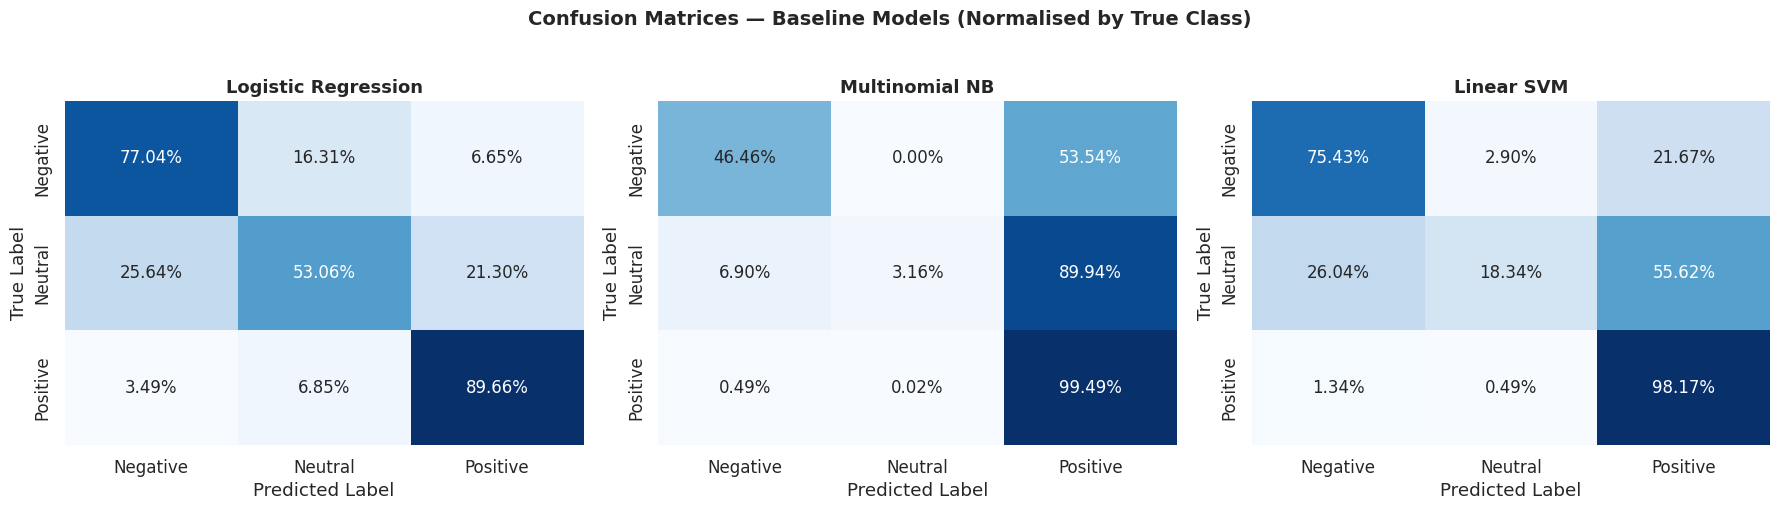

In [21]:
# ============================================================================
# Confusion Matrices (Visual)
# ============================================================================

def plot_confusion_matrices(evaluations, y_test):
    """
    Plot confusion matrices for all baseline models side by side.

    A confusion matrix shows where the model gets confused:
    - Diagonal = correct predictions
    - Off-diagonal = misclassifications
    - Normalised by true class (rows sum to 1.0) for comparability
    """
    target_names = ['Negative', 'Neutral', 'Positive']
    n_models = len(evaluations)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

    if n_models == 1:
        axes = [axes]

    for ax, (name, eval_data) in zip(axes, evaluations.items()):
        cm = confusion_matrix(y_test, eval_data['y_pred'], normalize='true')

        sns.heatmap(
            cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=ax, cbar=False,
            annot_kws={'size': 12}
        )
        ax.set_title(f'{name}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

    plt.suptitle('Confusion Matrices — Baseline Models (Normalised by True Class)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_confusion_matrices(baseline_evaluations, y_test)

## Baseline Comparison Summary

In [22]:
# ============================================================================
# Baseline Model Comparison Table
# ============================================================================

def build_comparison_table(results, evaluations):
    """
    Create a comprehensive comparison table of all baseline models.

    This table will be extended in Step 4 to include the DL model,
    forming the basis for the ML vs DL comparison in the report.
    """
    rows = []
    for name in results:
        rows.append({
            'Model': name,
            'Accuracy': evaluations[name]['accuracy'],
            'F1 (Macro)': evaluations[name]['f1_macro'],
            'F1 (Weighted)': evaluations[name]['f1_weighted'],
            'Train Time (s)': results[name]['train_time']
        })

    comparison_df = pd.DataFrame(rows)
    comparison_df = comparison_df.sort_values('F1 (Macro)', ascending=False)

    # Format for display
    display_df = comparison_df.copy()
    for col in ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']:
        display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
    display_df['Train Time (s)'] = display_df['Train Time (s)'].apply(
        lambda x: f'{x:.2f}'
    )

    print('=== Baseline Model Comparison (Test Set) ===')
    print(display_df.to_string(index=False))

    # Identify best model
    best = comparison_df.iloc[0]
    print(f'\n🏆 Best baseline: {best["Model"]} '
          f'(Macro F1 = {best["F1 (Macro)"]:.4f})')

    return comparison_df


baseline_comparison_df = build_comparison_table(
    baseline_results, baseline_evaluations
)

=== Baseline Model Comparison (Test Set) ===
              Model Accuracy F1 (Macro) F1 (Weighted) Train Time (s)
Logistic Regression   0.8539     0.6884        0.8667           3.36
         Linear SVM   0.8950     0.6656        0.8779           3.89
     Multinomial NB   0.8568     0.5291        0.8176           0.02

🏆 Best baseline: Logistic Regression (Macro F1 = 0.6884)


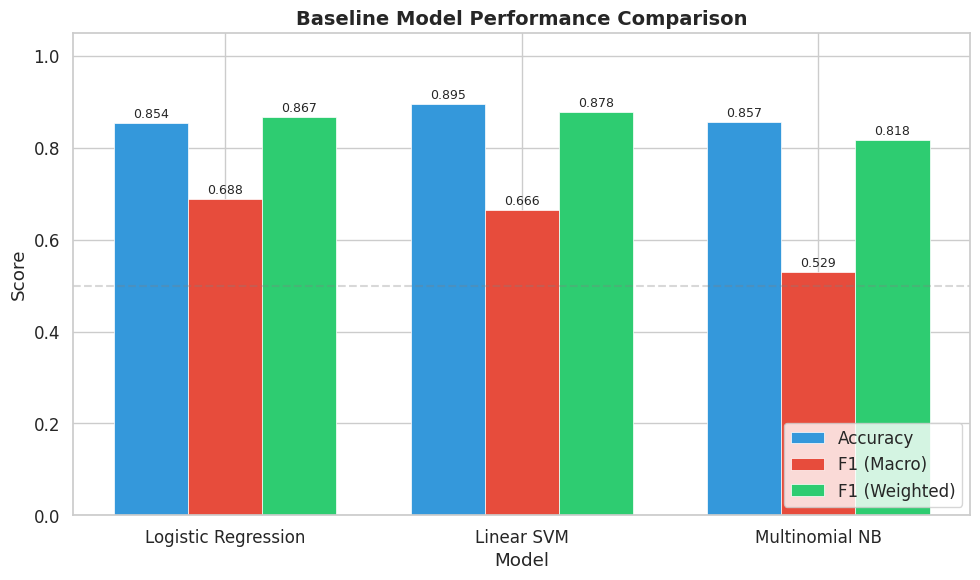

In [23]:
# ============================================================================
# Visual Comparison: Metric Bar Chart
# ============================================================================

def plot_baseline_comparison(comparison_df):
    """
    Bar chart comparing Accuracy, Macro F1, and Weighted F1 across baselines.

    This visualisation will be extended in Step 4 to include the DL model,
    providing a clear, visual answer to 'Is DL worth the complexity?'
    """
    metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
    models = comparison_df['Model'].tolist()
    n_models = len(models)
    n_metrics = len(metrics)

    x = np.arange(n_models)
    width = 0.25
    colors = ['#3498db', '#e74c3c', '#2ecc71']

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        values = comparison_df[metric].values
        bars = ax.bar(x + i * width, values, width,
                      label=metric, color=color,
                      edgecolor='white', linewidth=0.5)
        # Add value labels
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2.,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=9)

    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_title('Baseline Model Performance Comparison',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(models)
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
    ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.3,
               label='Random baseline')

    plt.tight_layout()
    plt.show()


plot_baseline_comparison(baseline_comparison_df)

---

## Summary
### Key Observations

- **TF-IDF + Linear SVM / Logistic Regression** are strong baselines for sentiment classification
- **Naive Bayes** typically underperforms due to its strong independence assumption
- **Neutral class** is the hardest to classify across all models (lowest F1) — this is expected because neutral reviews overlap linguistically with both positive and negative
- **Training time** is measured in seconds — this becomes a key comparison point against DL models that train for minutes/hours

### What These Baselines Cannot Do

These models treat text as a **bag of words** and cannot:
- Understand word order ("not good" vs "good")
- Capture long-range dependencies across sentences
- Learn contextual word representations

These limitations motivate the Bi-LSTM model, which processes text as a **sequence** and learns to weigh contextual relationships.


---


---

# Deep Learning Model Implementation

## Architecture: Bi-LSTM with Self-Attention

We implement a **Bidirectional Long Short-Term Memory (Bi-LSTM)** network with a **self-attention mechanism** for sentiment classification. This architecture is chosen over alternatives for specific, well-justified reasons:

### Why Bi-LSTM over Vanilla RNN?

| Issue | RNN | LSTM |
|-------|-----|------|
| **Vanishing gradient** | Gradients decay exponentially over long sequences, losing early context | **Gating mechanisms** (forget, input, output gates) control information flow, preserving long-range dependencies |
| **Long reviews** | Fails to connect "Not" at the start with "good" at the end | Forget gate selectively retains relevant context across 100+ tokens |

### Why Bidirectional?

A unidirectional LSTM reads left-to-right only. Sentiment, however, depends on **both surrounding contexts**:

- *"Despite the **problems**, it works **great**"* — forward pass captures "problems", backward pass captures "great"
- The Bi-LSTM concatenates both directions, providing a **richer representation** of each token

### Why Self-Attention?

Attention learns to **weight the importance of each word** in the sequence:
- Interpretability: We can visualise which words drove the prediction
- Performance: The model focuses on sentiment-bearing tokens rather than treating all positions equally

### Architecture Overview

```
Input Text → Tokenise → Numericalize → Pad/Truncate
          → Embedding Layer (GloVe 300d, fine-tuned)
          → Bi-LSTM (2 layers, hidden_dim=128, dropout=0.3)
          → Self-Attention (learns word importance)
          → FC(256→128) → ReLU → Dropout → FC(128→3)
          → 3-class prediction (Negative / Neutral / Positive)
```

---


## Vocabulary Building

Before we can feed text to a neural network, we must convert words to integers. We build a **vocabulary** — a mapping from words to unique indices — from the **training data only** (to prevent data leakage).

Key design choices:
- **Special tokens**: `<PAD>` (index 0) for padding, `<UNK>` (index 1) for unknown words
- **Minimum frequency**: Words appearing fewer than 2 times are mapped to `<UNK>` — this removes rare typos and noise while keeping the vocabulary manageable
- **Training-only construction**: The vocabulary is built exclusively on training data; validation/test words not in the vocabulary are mapped to `<UNK>`

In [24]:
# ============================================================================
# Vocabulary Construction
# ============================================================================

class Vocabulary:
    """
    Word-to-index mapping for converting text to numerical sequences.

    Built from training data only to prevent data leakage.
    Words below min_freq are mapped to <UNK>.

    Attributes:
        word2idx (dict): Word to integer index mapping.
        idx2word (dict): Integer index to word mapping (for decoding).
        PAD_IDX (int): Index for padding token (0).
        UNK_IDX (int): Index for unknown token (1).
    """

    PAD_TOKEN = '<PAD>'
    UNK_TOKEN = '<UNK>'
    PAD_IDX = 0
    UNK_IDX = 1

    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {self.PAD_TOKEN: self.PAD_IDX,
                         self.UNK_TOKEN: self.UNK_IDX}
        self.idx2word = {self.PAD_IDX: self.PAD_TOKEN,
                         self.UNK_IDX: self.UNK_TOKEN}
        self.word_freq = Counter()

    def build(self, texts):
        """
        Build vocabulary from a list of text strings.

        Only words with frequency >= min_freq are included.
        This filters out rare typos and noise while keeping
        informative terms.
        """
        # Count word frequencies
        for text in texts:
            self.word_freq.update(text.split())

        # Add words meeting the minimum frequency threshold
        for word, freq in self.word_freq.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, text):
        """Convert a text string to a list of integer indices."""
        return [self.word2idx.get(word, self.UNK_IDX)
                for word in text.split()]

    def __len__(self):
        return len(self.word2idx)


# Build vocabulary from TRAINING data only
MIN_FREQ = 2
vocab = Vocabulary(min_freq=MIN_FREQ)
vocab.build(train_df['review'].tolist())

# Report statistics
total_unique = len(vocab.word_freq)
print('=== Vocabulary Statistics ===')
print(f'Total unique words in training data: {total_unique:,}')
print(f'Words with freq >= {MIN_FREQ}:           {len(vocab):,}')
print(f'Words filtered out (freq < {MIN_FREQ}):   {total_unique - len(vocab) + 2:,}')
print(f'Special tokens:                      <PAD> (idx 0), <UNK> (idx 1)')
print(f'\nVocabulary size: {len(vocab):,}')

# Show most common words
print(f'\nTop 20 most frequent words:')
for word, freq in vocab.word_freq.most_common(20):
    print(f'  {word:>15}: {freq:,}')

=== Vocabulary Statistics ===
Total unique words in training data: 84,280
Words with freq >= 2:           32,462
Words filtered out (freq < 2):   51,820
Special tokens:                      <PAD> (idx 0), <UNK> (idx 1)

Vocabulary size: 32,462

Top 20 most frequent words:
              the: 114,530
                i: 68,635
               to: 68,243
              and: 68,099
                a: 63,055
               it: 51,084
               is: 42,445
              for: 36,827
             this: 34,677
               of: 30,588
               my: 29,827
             with: 24,309
               in: 23,678
             that: 23,049
               on: 19,440
              you: 19,258
             have: 18,759
              but: 18,268
              not: 18,112
              was: 14,339


## Pre-trained GloVe Embeddings

We initialise the embedding layer with **GloVe 6B 300-dimensional** pre-trained word vectors. This is a form of **transfer learning** that provides several advantages:

- **Semantic knowledge**: GloVe vectors encode semantic relationships learned from 6 billion tokens of text (Wikipedia + Gigaword). Words like "terrible" and "awful" will have similar representations before training even begins.
- **Faster convergence**: Starting with meaningful representations means the model learns sentiment patterns faster.
- **Better generalisation**: Pre-trained embeddings help with words that are infrequent in our training data but common in general English.

### Design Decision: Fine-tuning

We allow the embedding weights to be **updated during training** (fine-tuned). This adapts the general-purpose GloVe vectors to our specific sentiment classification task. For example, the word "decent" might shift closer to the positive or neutral cluster based on how Amazon reviewers use it.


In [25]:
# ============================================================================
# Download and Load GloVe Embeddings
# ============================================================================
import urllib.request
import zipfile
import os

GLOVE_DIR = 'glove'
GLOVE_FILE = os.path.join(GLOVE_DIR, 'glove.6B.300d.txt')
GLOVE_URL = 'https://nlp.stanford.edu/data/glove.6B.zip'
EMBEDDING_DIM = 300


def download_glove(url=GLOVE_URL, target_dir=GLOVE_DIR):
    """
    Download and extract GloVe embeddings if not already present.

    Downloads the GloVe 6B (trained on Wikipedia + Gigaword, ~822MB)
    and extracts the 300-dimensional vectors.
    """
    if os.path.exists(GLOVE_FILE):
        print(f'GloVe already downloaded at: {GLOVE_FILE}')
        return

    os.makedirs(target_dir, exist_ok=True)
    zip_path = os.path.join(target_dir, 'glove.6B.zip')

    print(f'Downloading GloVe embeddings (~822MB)...')
    urllib.request.urlretrieve(url, zip_path)
    print('Download complete. Extracting...')

    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(target_dir)

    os.remove(zip_path)  # Clean up zip file
    print(f'GloVe extracted to: {target_dir}/')


def load_glove_embeddings(glove_path, vocab, embedding_dim=300):
    """
    Create an embedding matrix aligned with our vocabulary using GloVe vectors.

    Process:
        1. Initialise matrix with small random values (for words not in GloVe)
        2. Set <PAD> vector to zeros (padding should not contribute to learning)
        3. For each GloVe word that exists in our vocabulary, copy its vector

    Args:
        glove_path: Path to GloVe text file.
        vocab: Vocabulary object with word2idx mapping.
        embedding_dim: Dimensionality of embeddings (300 for GloVe 6B).

    Returns:
        torch.Tensor: Embedding matrix of shape (vocab_size, embedding_dim).
    """
    # Initialise with small random values (Xavier-style)
    embedding_matrix = np.random.normal(
        0, 0.1, (len(vocab), embedding_dim)
    ).astype(np.float32)

    # <PAD> should be a zero vector
    embedding_matrix[vocab.PAD_IDX] = np.zeros(embedding_dim)

    # Load GloVe and match with our vocabulary
    found = 0
    print(f'Loading GloVe vectors from {glove_path}...')
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in vocab.word2idx:
                vector = np.array(values[1:], dtype=np.float32)
                if len(vector) == embedding_dim:
                    embedding_matrix[vocab.word2idx[word]] = vector
                    found += 1

    coverage = found / (len(vocab) - 2) * 100  # Exclude PAD, UNK
    print(f'\n=== GloVe Coverage ===')
    print(f'Vocabulary words found in GloVe: {found:,} / {len(vocab) - 2:,} '
          f'({coverage:.1f}%)')
    print(f'Words NOT in GloVe (random init): {len(vocab) - 2 - found:,}')
    print(f'Embedding matrix shape: {embedding_matrix.shape}')

    return torch.tensor(embedding_matrix, dtype=torch.float32)


# Download GloVe (skip if already present)
download_glove()

# Build embedding matrix aligned with our vocabulary
pretrained_embeddings = load_glove_embeddings(GLOVE_FILE, vocab, EMBEDDING_DIM)

GloVe already downloaded at: glove/glove.6B.300d.txt
Loading GloVe vectors from glove/glove.6B.300d.txt...

=== GloVe Coverage ===
Vocabulary words found in GloVe: 15,326 / 32,460 (47.2%)
Words NOT in GloVe (random init): 17,134
Embedding matrix shape: (32462, 300)


## Tokenized Dataset & DataLoaders

We now upgrade the data pipeline from Step 1.8 to handle **tokenised, numericalised sequences** ready for the Bi-LSTM:

1. **Truncation**: Reviews longer than `MAX_SEQ_LENGTH` are truncated (set based on the 95th percentile from EDA)
2. **Dynamic padding**: A custom `collate_fn` pads sequences to the longest in each batch (not globally), saving memory
3. **Packed sequences**: The LSTM receives sequence lengths to skip padding computations via `pack_padded_sequence`

In [26]:
# ============================================================================
# Tokenized Dataset & DataLoaders
# ============================================================================
import torch.nn as nn
import torch.nn.utils.rnn as rnn_utils

# Set max sequence length based on the 95th percentile of review lengths
# (computed in Step 1.5 EDA) — captures most reviews without excessive padding
MAX_SEQ_LENGTH = int(df['word_count'].quantile(0.95))
print(f'Max sequence length (95th percentile): {MAX_SEQ_LENGTH} words')


class TokenizedSentimentDataset(Dataset):
    """
    PyTorch Dataset that tokenises and numericalises review texts.

    Each review is converted from a string to a list of integer indices
    using the pre-built vocabulary. Reviews are truncated to max_length
    to manage memory; padding is handled dynamically in the collate_fn.

    Args:
        texts (list[str]): Cleaned review text strings.
        labels (list[int]): Sentiment labels (0, 1, 2).
        vocab (Vocabulary): Word-to-index mapping.
        max_length (int): Maximum sequence length (truncation point).
    """

    def __init__(self, texts, labels, vocab, max_length=200):
        assert len(texts) == len(labels)
        self.labels = labels
        self.vocab = vocab
        self.max_length = max_length

        # Pre-tokenise all texts for efficiency
        self.encoded = [
            self._encode(text) for text in texts
        ]

    def _encode(self, text):
        """Tokenise, truncate, and convert to integer indices."""
        tokens = text.split()[:self.max_length]
        return [self.vocab.word2idx.get(t, self.vocab.UNK_IDX)
                for t in tokens]

    def __len__(self):
        return len(self.encoded)

    def __getitem__(self, idx):
        return {
            'text_ids': torch.tensor(self.encoded[idx], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


def sentiment_collate_fn(batch):
    """
    Custom collate function for dynamic padding.

    Instead of padding all sequences to MAX_SEQ_LENGTH globally,
    we pad to the longest sequence IN EACH BATCH. This is more
    memory-efficient and reduces unnecessary computation.

    Returns:
        dict with:
            'text_ids': Padded tensor (batch_size, max_len_in_batch)
            'lengths':  Actual lengths tensor (batch_size,)
            'labels':   Label tensor (batch_size,)
    """
    texts = [item['text_ids'] for item in batch]
    labels = torch.stack([item['label'] for item in batch])
    lengths = torch.tensor([len(t) for t in texts], dtype=torch.long)

    # Pad to longest sequence in this batch (dynamic padding)
    texts_padded = rnn_utils.pad_sequence(
        texts, batch_first=True, padding_value=0
    )

    return {
        'text_ids': texts_padded,
        'lengths': lengths,
        'labels': labels
    }


# ── Create tokenized datasets ─────────────────────────────────────────────
train_tok_dataset = TokenizedSentimentDataset(
    train_df['review'].tolist(), train_df['sentiment'].tolist(),
    vocab, max_length=MAX_SEQ_LENGTH
)
val_tok_dataset = TokenizedSentimentDataset(
    val_df['review'].tolist(), val_df['sentiment'].tolist(),
    vocab, max_length=MAX_SEQ_LENGTH
)
test_tok_dataset = TokenizedSentimentDataset(
    test_df['review'].tolist(), test_df['sentiment'].tolist(),
    vocab, max_length=MAX_SEQ_LENGTH
)

# ── Create DataLoaders with custom collate ────────────────────────────────
BATCH_SIZE = 64

train_loader = DataLoader(
    train_tok_dataset, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=sentiment_collate_fn
)
val_loader = DataLoader(
    val_tok_dataset, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=sentiment_collate_fn
)
test_loader = DataLoader(
    test_tok_dataset, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=sentiment_collate_fn
)

# ── Verify ────────────────────────────────────────────────────────────────
sample = next(iter(train_loader))
print(f'\n=== Tokenized DataLoader Verification ===')
print(f'Batch text_ids shape: {sample["text_ids"].shape}')
print(f'Batch lengths:        {sample["lengths"][:5]} ...')
print(f'Batch labels:         {sample["labels"][:5]}')
print(f'\n✓ Tokenized data pipeline ready for Bi-LSTM.')

Max sequence length (95th percentile): 265 words

=== Tokenized DataLoader Verification ===
Batch text_ids shape: torch.Size([64, 265])
Batch lengths:        tensor([145,  46, 265, 151,  12]) ...
Batch labels:         tensor([2, 2, 1, 2, 0])

✓ Tokenized data pipeline ready for Bi-LSTM.


## Bi-LSTM Model Architecture

The model consists of four main components:

1. **Embedding Layer**: Converts word indices to 300-dim vectors (GloVe-initialised, fine-tunable)
2. **Bi-LSTM Encoder**: 2-layer bidirectional LSTM that reads the sequence in both directions, producing contextualised representations for each token
3. **Self-Attention**: Learns importance weights for each token, producing a single context vector by attending to the most sentiment-relevant words
4. **Classification Head**: Two fully-connected layers with ReLU activation and dropout, mapping the context vector to 3-class logits

### Hyperparameter Configuration

All hyperparameters are centralised in a configuration dictionary for easy experimentation:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `embedding_dim` | 300 | Matches GloVe 6B dimensionality |
| `hidden_dim` | 128 | Balanced capacity vs. overfitting risk for 50k samples |
| `n_layers` | 2 | Captures hierarchical features; more layers risk overfitting |
| `dropout` | 0.3 | Standard regularisation; prevents co-adaptation of neurons |
| `bidirectional` | True | Captures both forward and backward context |


In [27]:
# ============================================================================
# Bi-LSTM with Self-Attention Architecture
# ============================================================================

class SelfAttention(nn.Module):
    """
    Additive self-attention mechanism for sequence classification.

    Learns to assign importance weights to each token in the sequence,
    then produces a weighted sum (context vector) that emphasises
    sentiment-bearing words.

    This provides interpretability: we can inspect attention_weights
    to see which words the model considers most important for its
    prediction (used in Step 4 for evaluation).

    Args:
        hidden_dim (int): Size of input features (hidden_dim * 2 for Bi-LSTM).
    """

    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_output, mask=None):
        """
        Args:
            lstm_output: (batch, seq_len, hidden_dim) from Bi-LSTM.
            mask: (batch, seq_len) boolean mask — True for real tokens,
                  False for padding. Prevents attention on padding tokens.

        Returns:
            context: (batch, hidden_dim) weighted representation.
            weights: (batch, seq_len) attention distribution.
        """
        # Compute attention scores
        scores = self.attention(lstm_output).squeeze(-1)  # (batch, seq_len)

        # Mask padding positions with -inf (they become 0 after softmax)
        if mask is not None:
            scores = scores.masked_fill(~mask, float('-inf'))

        # Normalise to a probability distribution
        weights = torch.softmax(scores, dim=1)  # (batch, seq_len)

        # Weighted sum of LSTM outputs
        context = torch.bmm(
            weights.unsqueeze(1), lstm_output
        ).squeeze(1)  # (batch, hidden_dim)

        return context, weights


class BiLSTMSentiment(nn.Module):
    """
    Bidirectional LSTM with Self-Attention for Sentiment Classification.

    Architecture:
        Input → Embedding (GloVe) → Bi-LSTM → Self-Attention → FC → Output

    Design Decisions:
        - Packed sequences: Efficiently handles variable-length inputs
          by skipping computation on padding tokens in the LSTM.
        - Attention pooling: Replaces simple concat of final hidden states
          with a learned weighted combination of all timesteps.
        - Two FC layers: Provides a nonlinear classification head that
          can learn complex decision boundaries.

    Args:
        vocab_size (int): Size of vocabulary.
        embedding_dim (int): Dimensionality of word embeddings.
        hidden_dim (int): Hidden size of LSTM (per direction).
        output_dim (int): Number of classes (3 for sentiment).
        n_layers (int): Number of stacked LSTM layers.
        dropout (float): Dropout probability.
        pad_idx (int): Index of <PAD> token.
        pretrained_embeddings (Tensor, optional): Pre-trained weight matrix.
    """

    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 n_layers, dropout, pad_idx, pretrained_embeddings=None):
        super().__init__()

        # ── Embedding Layer ───────────────────────────────────────────────
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=pad_idx
        )
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            # Allow fine-tuning to adapt GloVe vectors to our task
            self.embedding.weight.requires_grad = True

        # ── Bi-LSTM Encoder ───────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )

        # ── Self-Attention ────────────────────────────────────────────────
        self.attention = SelfAttention(hidden_dim * 2)  # *2 for bidirectional

        # ── Classification Head ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, text, lengths):
        """
        Forward pass.

        Args:
            text: (batch, seq_len) padded integer sequences.
            lengths: (batch,) actual lengths before padding.

        Returns:
            logits: (batch, output_dim) raw class scores.
            attention_weights: (batch, seq_len) for interpretability.
        """
        # Embed and apply dropout
        embedded = self.dropout(self.embedding(text))  # (batch, seq_len, emb_dim)

        # Pack sequences — LSTM skips padding computations
        packed = rnn_utils.pack_padded_sequence(
            embedded, lengths.cpu(),
            batch_first=True, enforce_sorted=False
        )
        packed_output, (hidden, cell) = self.lstm(packed)

        # Unpack back to padded format
        output, _ = rnn_utils.pad_packed_sequence(
            packed_output, batch_first=True
        )  # (batch, seq_len, hidden_dim * 2)

        # Create attention mask (True for real tokens, False for padding)
        max_len = output.size(1)
        mask = torch.arange(max_len, device=output.device).unsqueeze(0) < \
               lengths.unsqueeze(1).to(output.device)

        # Apply attention
        context, attn_weights = self.attention(output, mask)

        # Classify
        logits = self.classifier(context)

        return logits, attn_weights


print('✓ BiLSTMSentiment model class defined.')

✓ BiLSTMSentiment model class defined.


### Model Instantiation & Summary

We instantiate the model with our chosen hyperparameters and pre-trained GloVe embeddings, then move it to the available device (GPU if available on Azure, otherwise CPU).

In [28]:
# ============================================================================
# Model Instantiation
# ============================================================================

# ── Centralised Hyperparameters ───────────────────────────────────────────
# All hyperparameters in one place for easy experimentation
MODEL_CONFIG = {
    'vocab_size': len(vocab),
    'embedding_dim': EMBEDDING_DIM,  # 300 (matches GloVe)
    'hidden_dim': 128,               # Per-direction LSTM hidden size
    'output_dim': 3,                 # Negative, Neutral, Positive
    'n_layers': 2,                   # Stacked LSTM layers
    'dropout': 0.3,                  # Regularisation
    'pad_idx': vocab.PAD_IDX,        # 0
}

# ── Device Configuration ──────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Instantiate Model ─────────────────────────────────────────────────────
model = BiLSTMSentiment(
    **MODEL_CONFIG,
    pretrained_embeddings=pretrained_embeddings
).to(device)

# ── Model Summary ─────────────────────────────────────────────────────────
def count_parameters(model):
    """Count total and trainable parameters."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)

print(f'\n=== Model Summary ===')
print(model)
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'\n=== Hyperparameters ===')
for key, value in MODEL_CONFIG.items():
    print(f'  {key:>15}: {value}')

Using device: cuda

=== Model Summary ===
BiLSTMSentiment(
  (embedding): Embedding(32462, 300, padding_idx=0)
  (lstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): SelfAttention(
    (attention): Linear(in_features=256, out_features=1, bias=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters:     10,607,723
Trainable parameters: 10,607,723

=== Hyperparameters ===
       vocab_size: 32462
    embedding_dim: 300
       hidden_dim: 128
       output_dim: 3
         n_layers: 2
          dropout: 0.3
          pad_idx: 0


## Training Configuration

We configure the training loop with:

| Component | Choice | Rationale |
|-----------|--------|-----------|
| **Loss Function** | `CrossEntropyLoss(weight=...)` | Class-weighted loss to handle imbalance (from Step 1.6) |
| **Optimiser** | Adam (lr=1e-3) | Adaptive learning rates; robust default for LSTM training |
| **LR Scheduler** | ReduceLROnPlateau | Halves LR when validation loss plateaus — prevents overshooting |
| **Early Stopping** | Patience=5 | Stops training when validation loss stops improving — prevents overfitting |
| **Gradient Clipping** | max_norm=5.0 | Prevents exploding gradients, a common issue in RNNs/LSTMs |

In [29]:
# ============================================================================
# Training Configuration
# ============================================================================

class EarlyStopping:
    """
    Early stopping to terminate training when validation loss stops improving.

    Monitors validation loss and triggers a stop if it hasn't improved
    for 'patience' consecutive epochs. This prevents overfitting by
    stopping before the model memorises the training data.

    Args:
        patience (int): Epochs to wait before stopping.
        min_delta (float): Minimum improvement to count as progress.
    """

    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


# ── Training Hyperparameters ──────────────────────────────────────────────
TRAIN_CONFIG = {
    'learning_rate': 1e-3,
    'num_epochs': 20,
    'patience': 5,
    'grad_clip': 5.0,
    'scheduler_factor': 0.5,     # Halve LR on plateau
    'scheduler_patience': 2,     # Wait 2 epochs before reducing LR
}

# ── Loss Function (with class weights from Step 1.6) ─────────────────────
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device)
)

# ── Optimiser ─────────────────────────────────────────────────────────────
optimiser = torch.optim.Adam(
    model.parameters(),
    lr=TRAIN_CONFIG['learning_rate']
)

# ── Learning Rate Scheduler ───────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,
    mode='min',
    factor=TRAIN_CONFIG['scheduler_factor'],
    patience=TRAIN_CONFIG['scheduler_patience'],
)

# ── Early Stopping ────────────────────────────────────────────────────────
early_stopping = EarlyStopping(patience=TRAIN_CONFIG['patience'])

print('=== Training Configuration ===')
for key, value in TRAIN_CONFIG.items():
    print(f'  {key:>20}: {value}')
print(f'  {"device":>20}: {device}')
print(f'  {"class_weights":>20}: {class_weights_tensor.numpy().round(4)}')

=== Training Configuration ===
         learning_rate: 0.001
            num_epochs: 20
              patience: 5
             grad_clip: 5.0
      scheduler_factor: 0.5
    scheduler_patience: 2
                device: cuda
         class_weights: [2.5448 4.6784 0.4178]


## Training Loop

The training process follows this cycle each epoch:

1. **Train**: Forward pass → compute weighted loss → backpropagate → clip gradients → update weights
2. **Validate**: Forward pass (no gradients) → compute loss and accuracy
3. **Schedule**: Reduce learning rate if validation loss plateaus
4. **Checkpoint**: Save the model with the best validation loss
5. **Early stop**: Halt training if no improvement for `patience` epochs

In [30]:
# ============================================================================
# Training & Evaluation Functions
# ============================================================================

def train_one_epoch(model, loader, optimiser, criterion, device, clip=5.0):
    """
    Train the model for one epoch.

    Args:
        model: The BiLSTMSentiment model.
        loader: Training DataLoader.
        optimiser: Adam optimiser.
        criterion: Weighted CrossEntropyLoss.
        device: GPU/CPU device.
        clip: Maximum gradient norm for clipping.

    Returns:
        Tuple of (average_loss, accuracy).
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        text_ids = batch['text_ids'].to(device)
        lengths = batch['lengths']
        labels = batch['labels'].to(device)

        # Forward pass
        optimiser.zero_grad()
        logits, _ = model(text_ids, lengths)
        loss = criterion(logits, labels)

        # Backward pass with gradient clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimiser.step()

        # Track metrics
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate_one_epoch(model, loader, criterion, device):
    """
    Evaluate the model on validation/test data (no gradient computation).

    Returns:
        Tuple of (average_loss, accuracy).
    """
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            text_ids = batch['text_ids'].to(device)
            lengths = batch['lengths']
            labels = batch['labels'].to(device)

            logits, _ = model(text_ids, lengths)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


print('✓ Training and evaluation functions defined.')

✓ Training and evaluation functions defined.


In [31]:
# ============================================================================
# Main Training Loop
# ============================================================================

# Training history for plotting
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_val_loss = float('inf')
MODEL_PATH = 'best_bilstm_model.pt'

print(f'Training Bi-LSTM for up to {TRAIN_CONFIG["num_epochs"]} epochs...\n')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | '
      f'{"Val Loss":>8} | {"Val Acc":>7} | {"LR":>10} | Status')
print('-' * 80)

for epoch in range(TRAIN_CONFIG['num_epochs']):

    # Train and evaluate
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimiser, criterion,
        device, clip=TRAIN_CONFIG['grad_clip']
    )
    val_loss, val_acc = evaluate_one_epoch(
        model, val_loader, criterion, device
    )

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Current learning rate
    current_lr = optimiser.param_groups[0]['lr']

    # Status message
    status = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        status = '✓ Best model saved'

    print(f'{epoch + 1:>5} | {train_loss:>10.4f} | {train_acc:>8.4f} | '
          f'{val_loss:>8.4f} | {val_acc:>7.4f} | {current_lr:>10.6f} | {status}')

    # Learning rate scheduler
    scheduler.step(val_loss)

    # Early stopping check
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f'\n⚠️  Early stopping triggered at epoch {epoch + 1} '
              f'(no improvement for {TRAIN_CONFIG["patience"]} epochs)')
        break

# Load the best model for evaluation
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
print(f'\n✓ Training complete. Best model loaded from epoch with '
      f'val_loss = {best_val_loss:.4f}')

Training Bi-LSTM for up to 20 epochs...

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR | Status
--------------------------------------------------------------------------------
    1 |     0.7769 |   0.7377 |   0.6649 |  0.7886 |   0.001000 | ✓ Best model saved
    2 |     0.5570 |   0.8286 |   0.6121 |  0.8389 |   0.001000 | ✓ Best model saved
    3 |     0.4023 |   0.8750 |   0.7967 |  0.8649 |   0.001000 | 
    4 |     0.2722 |   0.9157 |   1.0021 |  0.8731 |   0.001000 | 
    5 |     0.1676 |   0.9449 |   1.1016 |  0.8180 |   0.001000 | 
    6 |     0.0923 |   0.9678 |   1.8140 |  0.8697 |   0.000500 | 
    7 |     0.0692 |   0.9742 |   1.8424 |  0.8532 |   0.000500 | 

⚠️  Early stopping triggered at epoch 7 (no improvement for 5 epochs)

✓ Training complete. Best model loaded from epoch with val_loss = 0.6121


## Training Curves

Visualising loss and accuracy across epochs helps diagnose:
- **Overfitting**: training loss decreasing while validation loss increases
- **Underfitting**: both losses remain high
- **Good fit**: both losses decrease and converge

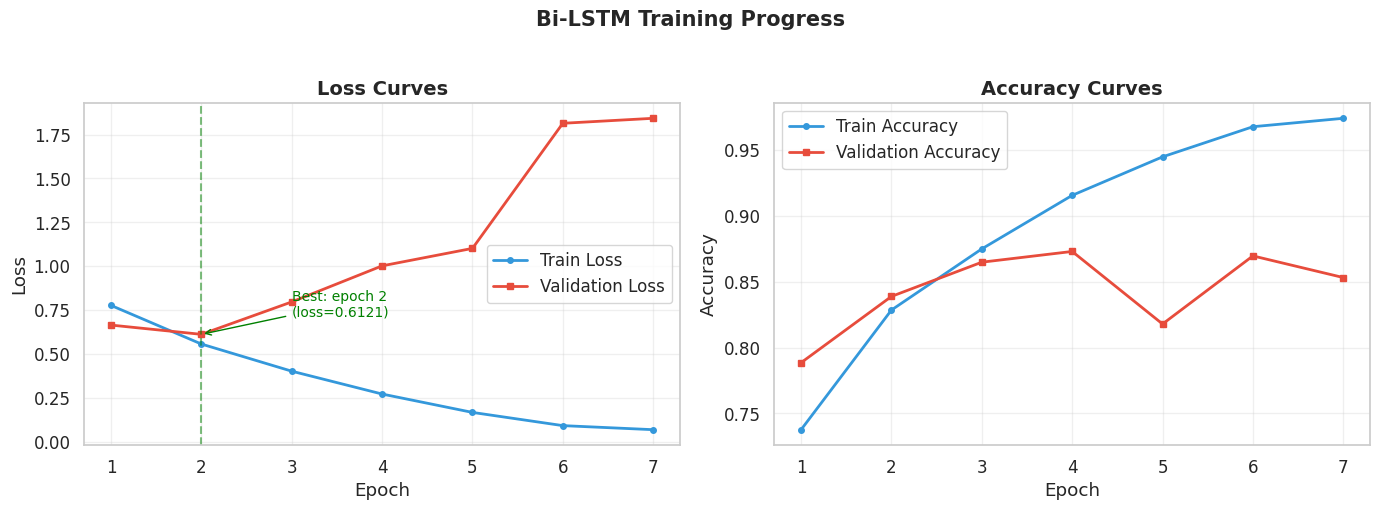


=== Training Summary ===
Total epochs trained:  7
Best epoch:            2
Best validation loss:  0.6121
Best validation acc:   0.8389


In [32]:
# ============================================================================
# Training Curves Visualisation
# ============================================================================

def plot_training_curves(history):
    """
    Plot training and validation loss/accuracy curves.

    These curves are essential for diagnosing model behaviour:
    - Diverging curves → overfitting
    - Converging curves → well-generalised model
    - Flat curves → underfitting (model not learning)
    """
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Loss Curves ───────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs, history['train_loss'], 'o-',
            color='#3498db', label='Train Loss', linewidth=2, markersize=4)
    ax.plot(epochs, history['val_loss'], 's-',
            color='#e74c3c', label='Validation Loss', linewidth=2, markersize=4)
    ax.set_title('Loss Curves', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Mark best epoch
    best_epoch = np.argmin(history['val_loss']) + 1
    best_loss = min(history['val_loss'])
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
    ax.annotate(f'Best: epoch {best_epoch}\n(loss={best_loss:.4f})',
                xy=(best_epoch, best_loss),
                xytext=(best_epoch + 1, best_loss + 0.1),
                arrowprops=dict(arrowstyle='->', color='green'),
                fontsize=10, color='green')

    # ── Accuracy Curves ───────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.plot(epochs, history['train_acc'], 'o-',
             color='#3498db', label='Train Accuracy', linewidth=2, markersize=4)
    ax2.plot(epochs, history['val_acc'], 's-',
             color='#e74c3c', label='Validation Accuracy', linewidth=2, markersize=4)
    ax2.set_title('Accuracy Curves', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Bi-LSTM Training Progress',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print final stats
    print(f'\n=== Training Summary ===')
    print(f'Total epochs trained:  {len(history["train_loss"])}')
    print(f'Best epoch:            {best_epoch}')
    print(f'Best validation loss:  {best_loss:.4f}')
    print(f'Best validation acc:   {history["val_acc"][best_epoch - 1]:.4f}')


plot_training_curves(history)

---

## Summary
### Architecture Highlights

- **Bi-LSTM** solves the vanishing gradient problem via **gating mechanisms** and captures bidirectional context
- **Self-attention** provides interpretability (word-level importance scores) and adaptive pooling
- **GloVe embeddings** provide transfer learning from 6B tokens of general English text
- **Packed sequences** ensure efficient computation by skipping padding tokens


---


---

# Transformer Model Implementation

Having implemented the Bi-LSTM with Self-Attention in Step 3, we now build a **Transformer encoder** model for the same sentiment classification task. Comparing these two architectures enriches the critical reflection report by contrasting:

| Aspect | Bi-LSTM | Transformer |
|--------|---------|-------------|
| **Sequence processing** | Sequential (token-by-token) | Fully parallel (all tokens at once) |
| **Long-range dependencies** | Gating mitigates vanishing gradients, but signal still decays over distance | Self-attention directly connects any two positions — no decay |
| **Attention mechanism** | Additive attention over LSTM outputs | Multi-head self-attention at every layer |
| **Positional information** | Implicit via recurrence order | Explicit via positional encoding |
| **Training efficiency** | Cannot parallelise across time steps | Highly parallelisable on GPUs |



We reuse the **same GloVe 300d embeddings, vocabulary, data pipeline, and training functions** so that the only variable is the encoder architecture — ensuring a fair comparison.


## Transformer Architecture

The model follows the **encoder-only** Transformer design (Vaswani et al., 2017):

```
Input → Embedding (GloVe 300d) → Scale by √d_model → Positional Encoding
      → TransformerEncoder (N layers of Multi-Head Self-Attention + FFN)
      → Mean Pooling (over non-padded tokens)
      → FC Head → 3-class output
```

### Key Components

1. **Sinusoidal Positional Encoding** — Injects sequence-order information using sine and cosine functions of different frequencies. Unlike learned embeddings, this generalises to unseen sequence lengths and adds no trainable parameters.

2. **Multi-Head Self-Attention** — Each head attends to different aspects of the input. With 4 heads on 300-dimensional embeddings, each head operates on 75-dimensional projections.

3. **Mean Pooling** — We average all non-padded token representations to produce a fixed-size sentence vector. This is preferred over using a `[CLS]` token (which would require adding a token not present in our GloVe vocabulary).

4. **Classification Head** — Same structure as the Bi-LSTM (Linear → ReLU → Dropout → Linear) for a fair comparison.


In [33]:
# ============================================================================
# Transformer with Sinusoidal Positional Encoding
# ============================================================================

import math


class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding from "Attention Is All You Need"
    (Vaswani et al., 2017).

    Adds fixed sinusoidal signals to the embedding vectors so the
    Transformer can distinguish token positions. Even dimensions use
    sine; odd dimensions use cosine, with wavelengths forming a
    geometric progression from 2π to 10000·2π.

    Args:
        d_model (int): Embedding dimensionality.
        dropout (float): Dropout applied after adding positional encoding.
        max_len (int): Maximum sequence length supported.
    """

    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Pre-compute positional encodings (never updated by backprop)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """Add positional encoding to input embeddings."""
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerSentiment(nn.Module):
    """
    Transformer Encoder for Sentiment Classification.

    Architecture:
        Input → Embedding (GloVe) → Positional Encoding
              → TransformerEncoder → Mean Pooling → FC → Output

    Design Decisions:
        - Sinusoidal positional encoding: No extra parameters, generalises
          to unseen lengths, and is the canonical choice from the original
          Transformer paper.
        - Mean pooling: Averages all non-padded token representations.
          More stable than taking a single position (e.g., [CLS]) when
          no pre-training objective has trained that position.
        - Embedding scaling: Multiply by √d_model as per Vaswani et al.
          to prevent the positional encodings from dominating the signal.

    Args:
        vocab_size (int): Size of vocabulary.
        embedding_dim (int): Dimensionality of word embeddings (300 for GloVe).
        n_heads (int): Number of attention heads (must divide embedding_dim).
        n_layers (int): Number of TransformerEncoder layers.
        dim_feedforward (int): Hidden size of the feedforward network in each layer.
        output_dim (int): Number of classes (3 for sentiment).
        dropout (float): Dropout probability.
        max_seq_length (int): Maximum sequence length for positional encoding.
        pad_idx (int): Index of <PAD> token.
        pretrained_embeddings (Tensor, optional): Pre-trained weight matrix.
    """

    def __init__(self, vocab_size, embedding_dim, n_heads, n_layers,
                 dim_feedforward, output_dim, dropout, max_seq_length,
                 pad_idx, pretrained_embeddings=None):
        super().__init__()

        self.embedding_dim = embedding_dim

        # ── Embedding Layer ───────────────────────────────────────────────
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=pad_idx
        )
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = True

        # ── Positional Encoding ───────────────────────────────────────────
        self.pos_encoder = PositionalEncoding(
            embedding_dim, dropout, max_seq_length
        )

        # ── Transformer Encoder ───────────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers
        )

        # ── Classification Head ───────────────────────────────────────────
        # Same structure as Bi-LSTM classifier for fair comparison
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embedding_dim // 2, output_dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, text, lengths):
        """
        Forward pass.

        Args:
            text: (batch, seq_len) padded integer sequences.
            lengths: (batch,) actual lengths before padding.

        Returns:
            logits: (batch, output_dim) raw class scores.
            attn_placeholder: None — attention weights are extracted
                separately for interpretability in Step 4.
        """
        # Scale embeddings by sqrt(d_model) as per Vaswani et al. (2017)
        embedded = self.embedding(text) * math.sqrt(self.embedding_dim)
        embedded = self.pos_encoder(embedded)

        # Padding mask: True = padded position (PyTorch convention)
        max_len = text.size(1)
        padding_mask = torch.arange(
            max_len, device=text.device
        ).unsqueeze(0) >= lengths.unsqueeze(1).to(text.device)

        # Transformer encoding
        encoded = self.transformer_encoder(
            embedded, src_key_padding_mask=padding_mask
        )

        # Mean pooling over non-padded tokens
        real_mask = ~padding_mask                          # True for real tokens
        mask_expanded = real_mask.unsqueeze(-1).float()    # (batch, seq, 1)
        summed = (encoded * mask_expanded).sum(dim=1)      # (batch, emb_dim)
        counts = mask_expanded.sum(dim=1).clamp(min=1)     # (batch, 1)
        pooled = summed / counts

        # Classify
        logits = self.classifier(pooled)

        return logits, None


print('✓ TransformerSentiment model class defined.')

✓ TransformerSentiment model class defined.


### Transformer Model Instantiation & Summary

We instantiate the Transformer with hyperparameters chosen for a fair comparison with the Bi-LSTM:
- **Same GloVe 300d embeddings** — isolates the encoder as the only variable
- **4 attention heads** — 300 ÷ 4 = 75 dimensions per head (clean division)
- **2 encoder layers** — matches the 2-layer Bi-LSTM
- **Comparable parameter count** — ensures neither model has an unfair capacity advantage

In [34]:
# ============================================================================
# Transformer Model Instantiation
# ============================================================================

# ── Centralised Hyperparameters ───────────────────────────────────────────
TRANSFORMER_CONFIG = {
    'vocab_size': len(vocab),
    'embedding_dim': EMBEDDING_DIM,       # 300 (matches GloVe)
    'n_heads': 4,                          # 300 / 4 = 75 dims per head
    'n_layers': 2,                         # Encoder layers
    'dim_feedforward': 512,                # FFN hidden dimension
    'output_dim': 3,                       # Negative, Neutral, Positive
    'dropout': 0.3,                        # Regularisation
    'max_seq_length': MAX_SEQ_LENGTH + 10, # Slight buffer for positional enc.
    'pad_idx': vocab.PAD_IDX,              # 0
}

# ── Instantiate Model ─────────────────────────────────────────────────────
transformer_model = TransformerSentiment(
    **TRANSFORMER_CONFIG,
    pretrained_embeddings=pretrained_embeddings
).to(device)

# ── Model Summary ─────────────────────────────────────────────────────────
t_total, t_trainable = count_parameters(transformer_model)

print('=== Transformer Model Summary ===')
print(transformer_model)
print(f'\nTotal parameters:     {t_total:,}')
print(f'Trainable parameters: {t_trainable:,}')
print(f'\n=== Hyperparameters ===')
for key, value in TRANSFORMER_CONFIG.items():
    print(f'  {key:>18}: {value}')

# ── Compare parameter counts ─────────────────────────────────────────────
bilstm_total, _ = count_parameters(model)
print(f'\n=== Parameter Comparison ===')
print(f'  Bi-LSTM:      {bilstm_total:>12,}')
print(f'  Transformer:  {t_total:>12,}')
print(f'  Ratio:        {t_total / bilstm_total:.2f}x')

=== Transformer Model Summary ===
TransformerSentiment(
  (embedding): Embedding(32462, 300, padding_idx=0)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=300, out_features=300, bias=True)
        )
        (linear1): Linear(in_features=300, out_features=512, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=512, out_features=300, bias=True)
        (norm1): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((300,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=300, out_features=150, bias=True)

## Transformer Training Configuration

We use **identical training hyperparameters** to the Bi-LSTM (learning rate, patience, scheduler, class weights) so any performance difference is attributable solely to the architecture, not the training recipe.

In [35]:
# ============================================================================
# Transformer Training Configuration
# ============================================================================

# Reuse the same training hyperparameters for a fair comparison
TRANSFORMER_TRAIN_CONFIG = {
    'learning_rate': 1e-3,
    'num_epochs': 20,
    'patience': 5,
    'grad_clip': 5.0,
    'scheduler_factor': 0.5,
    'scheduler_patience': 2,
}

# ── Loss Function (same weighted CrossEntropyLoss) ───────────────────────
transformer_criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device)
)

# ── Fresh Optimiser for Transformer ──────────────────────────────────────
transformer_optimiser = torch.optim.Adam(
    transformer_model.parameters(),
    lr=TRANSFORMER_TRAIN_CONFIG['learning_rate']
)

# ── Learning Rate Scheduler ──────────────────────────────────────────────
transformer_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    transformer_optimiser,
    mode='min',
    factor=TRANSFORMER_TRAIN_CONFIG['scheduler_factor'],
    patience=TRANSFORMER_TRAIN_CONFIG['scheduler_patience']
)

# ── Early Stopping (fresh instance) ──────────────────────────────────────
transformer_early_stopping = EarlyStopping(
    patience=TRANSFORMER_TRAIN_CONFIG['patience']
)

print('=== Transformer Training Configuration ===')
for key, value in TRANSFORMER_TRAIN_CONFIG.items():
    print(f'  {key:>20}: {value}')

=== Transformer Training Configuration ===
         learning_rate: 0.001
            num_epochs: 20
              patience: 5
             grad_clip: 5.0
      scheduler_factor: 0.5
    scheduler_patience: 2


## Transformer Training Loop

We reuse the **same `train_one_epoch` and `evaluate_one_epoch` functions**. This is possible because the Transformer shares the same forward signature: `model(text_ids, lengths) → (logits, _)`.

The same data loaders, collate function, and batch format are used — the only difference is the model being trained.

In [36]:
# ============================================================================
# Transformer Training Loop
# ============================================================================

# Training history
transformer_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_transformer_val_loss = float('inf')
TRANSFORMER_MODEL_PATH = 'best_transformer_model.pt'

print(f'Training Transformer for up to {TRANSFORMER_TRAIN_CONFIG["num_epochs"]} epochs...\n')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | '
      f'{"Val Loss":>8} | {"Val Acc":>7} | {"LR":>10} | Status')
print('-' * 80)

for epoch in range(TRANSFORMER_TRAIN_CONFIG['num_epochs']):

    # Train and evaluate (reusing the same functions from Step 3.6a)
    train_loss, train_acc = train_one_epoch(
        transformer_model, train_loader, transformer_optimiser,
        transformer_criterion, device,
        clip=TRANSFORMER_TRAIN_CONFIG['grad_clip']
    )
    val_loss, val_acc = evaluate_one_epoch(
        transformer_model, val_loader, transformer_criterion, device
    )

    # Record history
    transformer_history['train_loss'].append(train_loss)
    transformer_history['val_loss'].append(val_loss)
    transformer_history['train_acc'].append(train_acc)
    transformer_history['val_acc'].append(val_acc)

    # Current learning rate
    current_lr = transformer_optimiser.param_groups[0]['lr']

    # Checkpoint best model
    status = ''
    if val_loss < best_transformer_val_loss:
        best_transformer_val_loss = val_loss
        torch.save(transformer_model.state_dict(), TRANSFORMER_MODEL_PATH)
        status = '✓ Best model saved'

    print(f'{epoch + 1:>5} | {train_loss:>10.4f} | {train_acc:>8.4f} | '
          f'{val_loss:>8.4f} | {val_acc:>7.4f} | {current_lr:>10.6f} | {status}')

    # Learning rate scheduler
    transformer_scheduler.step(val_loss)

    # Early stopping check
    transformer_early_stopping(val_loss)
    if transformer_early_stopping.early_stop:
        print(f'\n⚠️  Early stopping triggered at epoch {epoch + 1} '
              f'(no improvement for {TRANSFORMER_TRAIN_CONFIG["patience"]} epochs)')
        break

# Load the best model
transformer_model.load_state_dict(
    torch.load(TRANSFORMER_MODEL_PATH, map_location=device)
)
print(f'\n✓ Transformer training complete. Best model loaded from {TRANSFORMER_MODEL_PATH}.')

Training Transformer for up to 20 epochs...

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR | Status
--------------------------------------------------------------------------------
    1 |     0.8670 |   0.6829 |   0.8693 |  0.7378 |   0.001000 | ✓ Best model saved
    2 |     0.8221 |   0.7174 |   0.8749 |  0.7705 |   0.001000 | 
    3 |     0.8174 |   0.7146 |   0.8080 |  0.7830 |   0.001000 | ✓ Best model saved
    4 |     0.8099 |   0.7275 |   1.2742 |  0.8471 |   0.001000 | 
    5 |     0.8118 |   0.7202 |   0.9721 |  0.8143 |   0.001000 | 
    6 |     0.8242 |   0.7079 |   0.8815 |  0.8263 |   0.001000 | 
    7 |     0.7898 |   0.7255 |   1.0290 |  0.8281 |   0.000500 | 
    8 |     0.7969 |   0.7199 |   1.1780 |  0.8275 |   0.000500 | 

⚠️  Early stopping triggered at epoch 8 (no improvement for 5 epochs)

✓ Transformer training complete. Best model loaded from best_transformer_model.pt.


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


## Transformer Training Curves

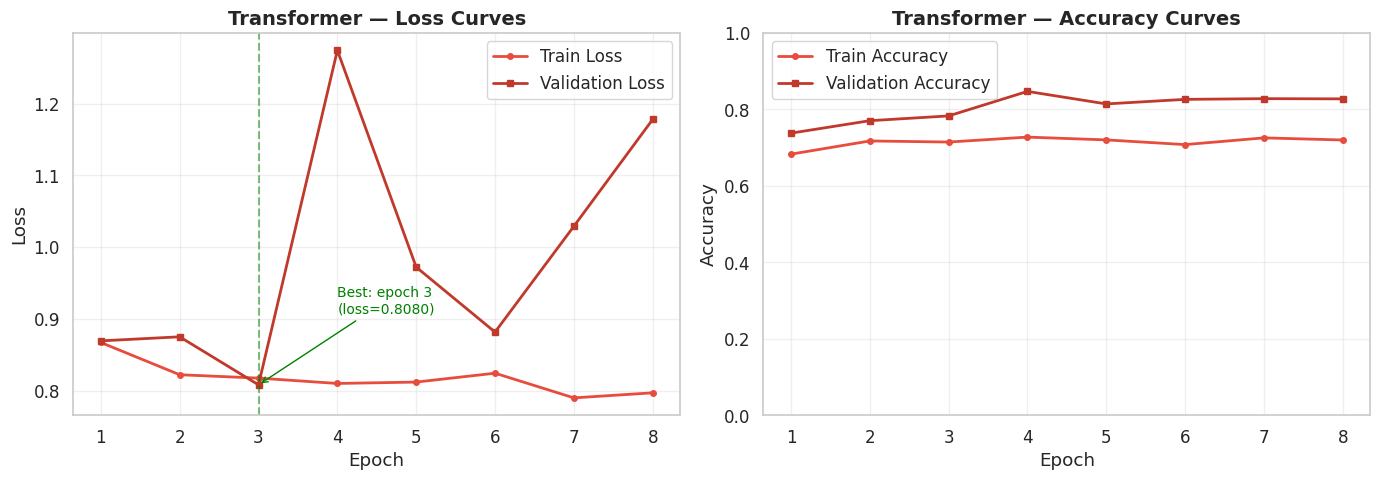

In [37]:
# ============================================================================
# Transformer Training Curves
# ============================================================================

epochs = range(1, len(transformer_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss Curves ───────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, transformer_history['train_loss'], 'o-',
        color='#e74c3c', label='Train Loss', linewidth=2, markersize=4)
ax.plot(epochs, transformer_history['val_loss'], 's-',
        color='#c0392b', label='Validation Loss', linewidth=2, markersize=4)
ax.set_title('Transformer — Loss Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Mark best epoch
best_epoch = np.argmin(transformer_history['val_loss']) + 1
best_loss = min(transformer_history['val_loss'])
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
ax.annotate(f'Best: epoch {best_epoch}\n(loss={best_loss:.4f})',
            xy=(best_epoch, best_loss),
            xytext=(best_epoch + 1, best_loss + 0.1),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green')

# ── Accuracy Curves ───────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs, transformer_history['train_acc'], 'o-',
         color='#e74c3c', label='Train Accuracy', linewidth=2, markersize=4)
ax2.plot(epochs, transformer_history['val_acc'], 's-',
         color='#c0392b', label='Validation Accuracy', linewidth=2, markersize=4)
ax2.set_title('Transformer — Accuracy Curves', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Architecture Comparison: Bi-LSTM vs Transformer

A direct comparison of the two architectures trained under identical conditions (same data, embeddings, loss function, and hyperparameters). Any performance difference is attributable to the **encoder architecture alone**.

=== Architecture Comparison: Bi-LSTM vs Transformer ===

                  Metric    Bi-LSTM Transformer
    Best Validation Loss     0.6121      0.8080
Best Validation Accuracy     0.8389      0.7830
              Best Epoch          2           3
    Total Epochs Trained          7           8
        Total Parameters 10,607,723  11,125,027
    Trainable Parameters 10,607,723  11,125,027


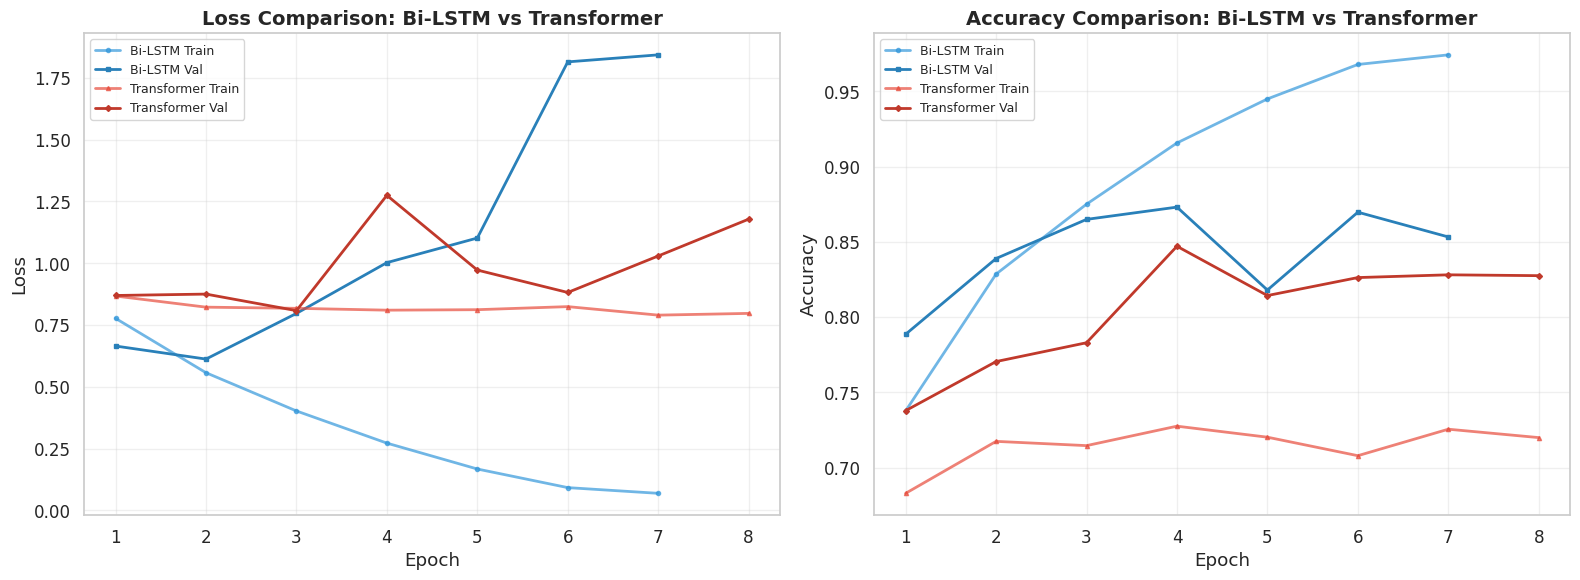


✓ Comparison plot saved to bilstm_vs_transformer_comparison.png


In [38]:
# ============================================================================
# Architecture Comparison: Bi-LSTM vs Transformer
# ============================================================================

import time

# ── Metrics Comparison Table ──────────────────────────────────────────────
bilstm_best_epoch = np.argmin(history['val_loss']) + 1
transformer_best_epoch = np.argmin(transformer_history['val_loss']) + 1

comparison_data = {
    'Metric': [
        'Best Validation Loss',
        'Best Validation Accuracy',
        'Best Epoch',
        'Total Epochs Trained',
        'Total Parameters',
        'Trainable Parameters',
    ],
    'Bi-LSTM': [
        f'{min(history["val_loss"]):.4f}',
        f'{history["val_acc"][bilstm_best_epoch - 1]:.4f}',
        str(bilstm_best_epoch),
        str(len(history['val_loss'])),
        f'{count_parameters(model)[0]:,}',
        f'{count_parameters(model)[1]:,}',
    ],
    'Transformer': [
        f'{min(transformer_history["val_loss"]):.4f}',
        f'{transformer_history["val_acc"][transformer_best_epoch - 1]:.4f}',
        str(transformer_best_epoch),
        str(len(transformer_history['val_loss'])),
        f'{count_parameters(transformer_model)[0]:,}',
        f'{count_parameters(transformer_model)[1]:,}',
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print('=== Architecture Comparison: Bi-LSTM vs Transformer ===\n')
print(comparison_df.to_string(index=False))

# ── Overlay Training Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss overlay
ax = axes[0]
epochs_lstm = range(1, len(history['val_loss']) + 1)
epochs_tf = range(1, len(transformer_history['val_loss']) + 1)

ax.plot(epochs_lstm, history['train_loss'], 'o-',
        color='#3498db', label='Bi-LSTM Train', linewidth=2, markersize=3, alpha=0.7)
ax.plot(epochs_lstm, history['val_loss'], 's-',
        color='#2980b9', label='Bi-LSTM Val', linewidth=2, markersize=3)
ax.plot(epochs_tf, transformer_history['train_loss'], '^-',
        color='#e74c3c', label='Transformer Train', linewidth=2, markersize=3, alpha=0.7)
ax.plot(epochs_tf, transformer_history['val_loss'], 'D-',
        color='#c0392b', label='Transformer Val', linewidth=2, markersize=3)
ax.set_title('Loss Comparison: Bi-LSTM vs Transformer', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Accuracy overlay
ax2 = axes[1]
ax2.plot(epochs_lstm, history['train_acc'], 'o-',
         color='#3498db', label='Bi-LSTM Train', linewidth=2, markersize=3, alpha=0.7)
ax2.plot(epochs_lstm, history['val_acc'], 's-',
         color='#2980b9', label='Bi-LSTM Val', linewidth=2, markersize=3)
ax2.plot(epochs_tf, transformer_history['train_acc'], '^-',
         color='#e74c3c', label='Transformer Train', linewidth=2, markersize=3, alpha=0.7)
ax2.plot(epochs_tf, transformer_history['val_acc'], 'D-',
         color='#c0392b', label='Transformer Val', linewidth=2, markersize=3)
ax2.set_title('Accuracy Comparison: Bi-LSTM vs Transformer', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bilstm_vs_transformer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Comparison plot saved to bilstm_vs_transformer_comparison.png')

---

## Summary
### Key Architecture Highlights 

**Bi-LSTM:**
- Solves the vanishing gradient problem via **gating mechanisms** (forget, input, output gates)
- **Bidirectionality** captures both forward and backward context
- **Self-attention** provides word-level importance scores for interpretability
- **Packed sequences** ensure efficient computation by skipping padding tokens

**Transformer:**
- **Parallelisation**: Processes all tokens simultaneously — no sequential bottleneck
- **Multi-head self-attention**: Every token attends to every other token directly, capturing long-range dependencies without signal decay
- **Sinusoidal positional encoding**: Injects order information without learnable parameters
- **State-of-the-art foundation**: The architecture underpinning BERT, GPT, and modern LLMs

---


---

# Model Evaluation 

We now evaluate **both** deep learning models (Bi-LSTM and Transformer) against the traditional ML baselines. This section covers:

1. **Test-set predictions** with probability outputs
2. **Classification reports** (precision, recall, F1 per class)
3. **Confusion matrices** (normalised)
4. **Unified ML vs DL comparison table**
5. **ROC curves & AUC** (one-vs-rest)
6. **Per-class accuracy breakdown**
7. **Bi-LSTM attention heatmaps** (interpretability)

## DL Model Test-Set Predictions

We run inference on the held-out **test set** using both trained models. We collect:
- **Predictions** (argmax of logits)
- **Probabilities** (softmax of logits — needed for ROC curves)
- **Attention weights** (Bi-LSTM only — for interpretability)

In [39]:
# ============================================================================
# DL Model Test-Set Predictions
# ============================================================================

def get_dl_predictions(model, loader, device):
    """
    Run inference on a DataLoader and collect predictions, probabilities,
    attention weights, token IDs, and lengths.

    Args:
        model: Trained DL model (BiLSTMSentiment or TransformerSentiment).
        loader: Test DataLoader.
        device: GPU/CPU device.

    Returns:
        dict with keys: 'preds', 'probs', 'labels', 'attn', 'text_ids', 'lengths'
    """
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    all_attn, all_text_ids, all_lengths = [], [], []

    with torch.no_grad():
        for batch in loader:
            text_ids = batch['text_ids'].to(device)
            lengths = batch['lengths']
            labels = batch['labels']

            logits, attn_weights = model(text_ids, lengths)
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_text_ids.extend(text_ids.cpu().numpy())
            all_lengths.extend(lengths.numpy())

            # Attention weights (Bi-LSTM returns tensor, Transformer returns None)
            if attn_weights is not None:
                all_attn.extend(attn_weights.cpu().numpy())

    return {
        'preds': np.array(all_preds),
        'probs': np.array(all_probs),
        'labels': np.array(all_labels),
        'attn': all_attn,
        'text_ids': all_text_ids,
        'lengths': np.array(all_lengths)
    }


# ── Get predictions for both models ──────────────────────────────────────
print('Running inference on test set...')
bilstm_results = get_dl_predictions(model, test_loader, device)
transformer_results = get_dl_predictions(transformer_model, test_loader, device)

# Shared test labels (same for both models)
y_test_dl = bilstm_results['labels']

print(f'\n✓ Bi-LSTM predictions:     {len(bilstm_results["preds"]):,} samples')
print(f'✓ Transformer predictions: {len(transformer_results["preds"]):,} samples')
print(f'✓ Attention weights:       {len(bilstm_results["attn"]):,} samples (Bi-LSTM only)')

Running inference on test set...

✓ Bi-LSTM predictions:     7,114 samples
✓ Transformer predictions: 7,114 samples
✓ Attention weights:       7,114 samples (Bi-LSTM only)


## Classification Reports (Both DL Models)

Per-class precision, recall, and F1-score on the test set. This mirrors the format for direct comparability with the ML baselines.

In [40]:
# ============================================================================
# Classification Reports (DL Models — Test Set)
# ============================================================================

target_names = ['Negative', 'Neutral', 'Positive']

dl_evaluations = {}

for name, results in [('Bi-LSTM', bilstm_results), ('Transformer', transformer_results)]:
    y_pred = results['preds']

    report = classification_report(
        y_test_dl, y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )

    acc = accuracy_score(y_test_dl, y_pred)
    f1_macro = f1_score(y_test_dl, y_pred, average='macro')
    f1_weighted = f1_score(y_test_dl, y_pred, average='weighted')

    dl_evaluations[name] = {
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'report': report
    }

    print(f'\n{"=" * 60}')
    print(f' {name} — Test Set Results')
    print(f'{"=" * 60}')
    print(report)


 Bi-LSTM — Test Set Results
              precision    recall  f1-score   support

    Negative     0.7481    0.7328    0.7404       932
     Neutral     0.2890    0.5917    0.3883       507
    Positive     0.9740    0.8862    0.9280      5675

    accuracy                         0.8451      7114
   macro avg     0.6704    0.7369    0.6856      7114
weighted avg     0.8956    0.8451    0.8650      7114


 Transformer — Test Set Results
              precision    recall  f1-score   support

    Negative     0.5562    0.7543    0.6403       932
     Neutral     0.1756    0.2919    0.2193       507
    Positive     0.9443    0.8331    0.8852      5675

    accuracy                         0.7842      7114
   macro avg     0.5587    0.6264    0.5816      7114
weighted avg     0.8386    0.7842    0.8057      7114



## Confusion Matrices (DL Models)

Normalised confusion matrices for both deep learning models, using the same visual style as the ML baselines. The diagonal shows correctly classified proportions; off-diagonal cells reveal systematic misclassification patterns.

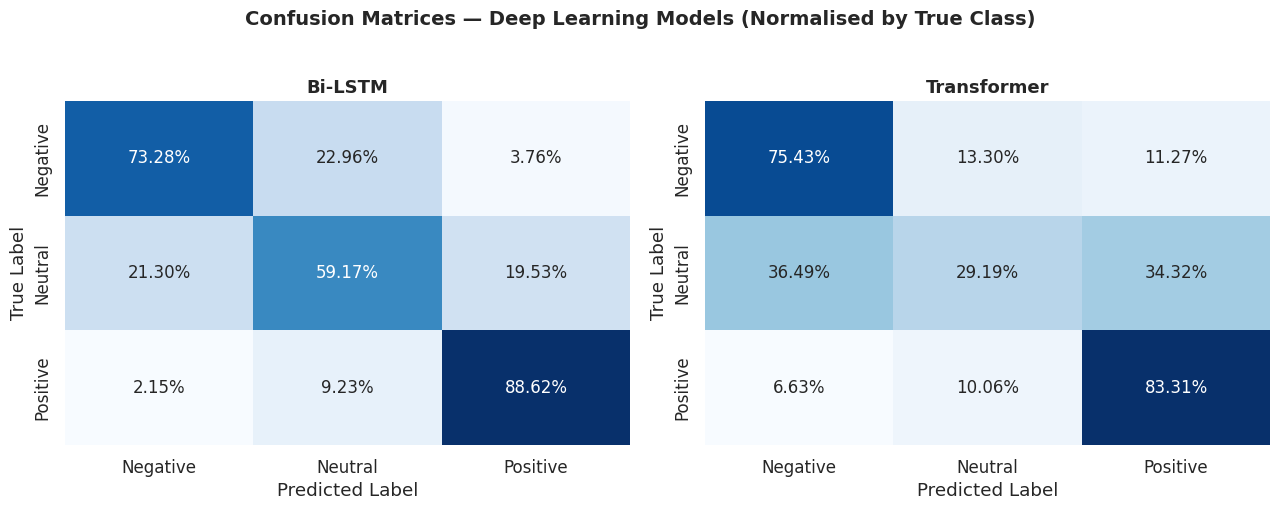

In [41]:
# ============================================================================
# Confusion Matrices (DL Models)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, eval_data) in zip(axes, dl_evaluations.items()):
    cm = confusion_matrix(y_test_dl, eval_data['y_pred'], normalize='true')

    sns.heatmap(
        cm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=target_names, yticklabels=target_names,
        ax=ax, cbar=False,
        annot_kws={'size': 12}
    )
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Deep Learning Models (Normalised by True Class)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Unified ML vs DL Comparison

We now combine all five models (3 ML baselines + 2 DL architectures) into a single comparison table.



In [42]:
# ============================================================================
# Unified ML vs DL Comparison Table
# ============================================================================

# ── Build unified table ──────────────────────────────────────────────────
unified_rows = []

# Add ML baselines from Step 2
for name in baseline_evaluations:
    unified_rows.append({
        'Model': name,
        'Type': 'ML',
        'Accuracy': baseline_evaluations[name]['accuracy'],
        'F1 (Macro)': baseline_evaluations[name]['f1_macro'],
        'F1 (Weighted)': baseline_evaluations[name]['f1_weighted'],
    })

# Add DL models
for name in dl_evaluations:
    unified_rows.append({
        'Model': name,
        'Type': 'DL',
        'Accuracy': dl_evaluations[name]['accuracy'],
        'F1 (Macro)': dl_evaluations[name]['f1_macro'],
        'F1 (Weighted)': dl_evaluations[name]['f1_weighted'],
    })

unified_df = pd.DataFrame(unified_rows)
unified_df = unified_df.sort_values('F1 (Macro)', ascending=False)

# Format for display
display_df = unified_df.copy()
for col in ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')

print('=== Unified Model Comparison (Test Set) ===\n')
print(display_df.to_string(index=False))

best = unified_df.iloc[0]
print(f'\n🏆 Best overall: {best["Model"]} (Macro F1 = {best["F1 (Macro)"]:.4f})')

=== Unified Model Comparison (Test Set) ===

              Model Type Accuracy F1 (Macro) F1 (Weighted)
Logistic Regression   ML   0.8539     0.6884        0.8667
            Bi-LSTM   DL   0.8451     0.6856        0.8650
         Linear SVM   ML   0.8950     0.6656        0.8779
        Transformer   DL   0.7842     0.5816        0.8057
     Multinomial NB   ML   0.8568     0.5291        0.8176

🏆 Best overall: Logistic Regression (Macro F1 = 0.6884)


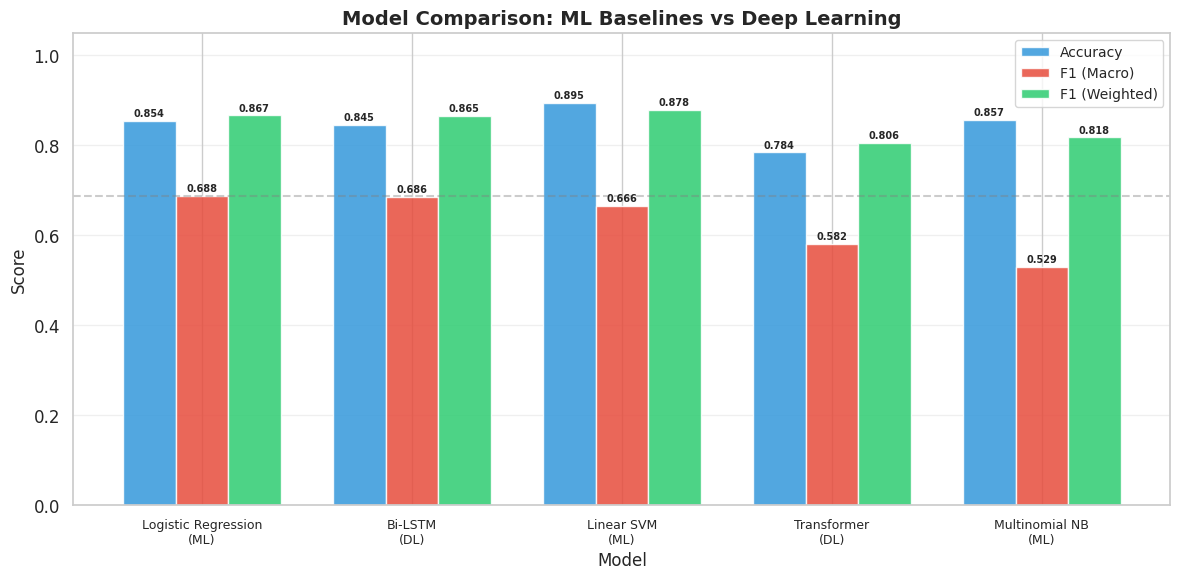


✓ Comparison chart saved to ml_vs_dl_comparison.png


In [43]:
# ============================================================================
# Visual Comparison: All Models Bar Chart
# ============================================================================

metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)']
models = unified_df['Model'].tolist()
types = unified_df['Type'].tolist()
n_models = len(models)
n_metrics = len(metrics)

x = np.arange(n_models)
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = unified_df[metric].values
    bars = ax.bar(x + i * width, values, width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# Style
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: ML Baselines vs Deep Learning',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'{m}\n({t})' for m, t in zip(models, types)],
                   fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim([0, 1.05])
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=unified_df[unified_df['Type'] == 'ML']['F1 (Macro)'].max(),
           color='gray', linestyle='--', alpha=0.4, label='Best ML baseline')

plt.tight_layout()
plt.savefig('ml_vs_dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Comparison chart saved to ml_vs_dl_comparison.png')

## ROC Curves & AUC (One-vs-Rest)

ROC (Receiver Operating Characteristic) curves plot the **True Positive Rate vs False Positive Rate** at various classification thresholds. The **Area Under the Curve (AUC)** summarises discriminative ability:
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random guessing

We compute one-vs-rest ROC curves for each sentiment class, for both DL models.

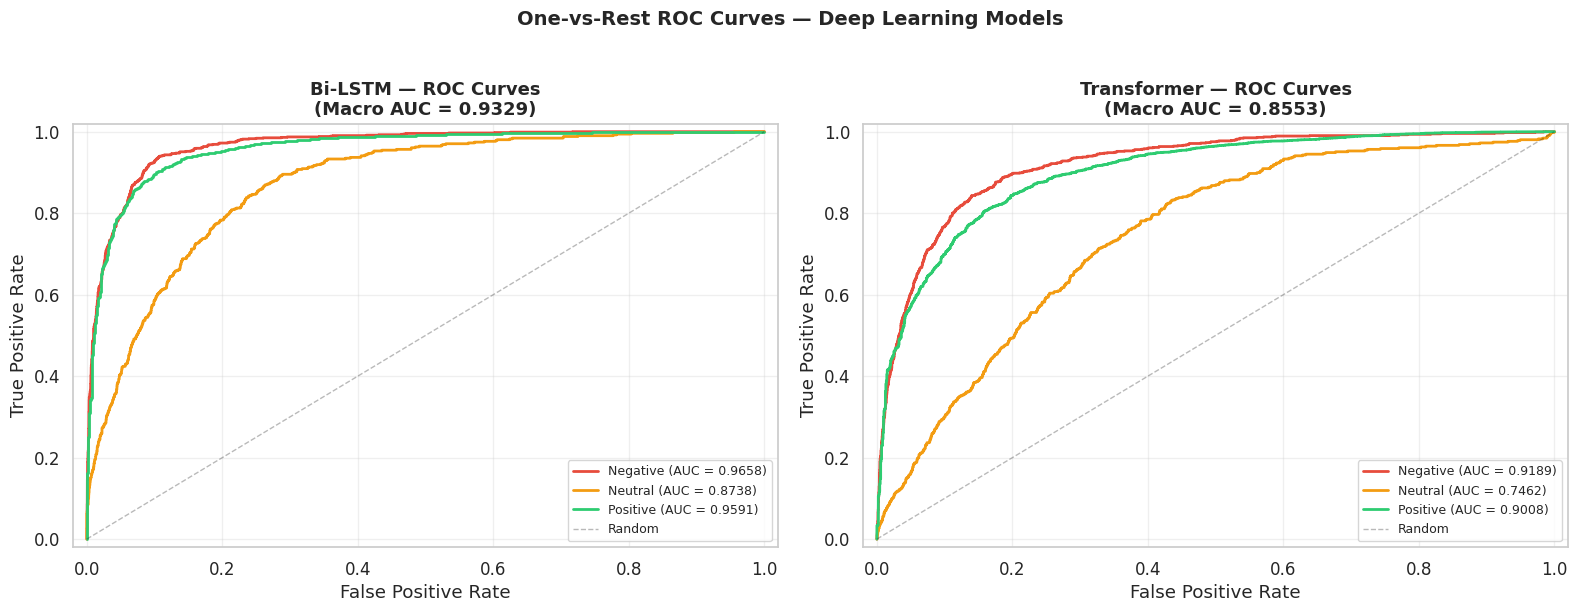

✓ ROC curves saved to roc_curves_dl.png


In [44]:
# ============================================================================
# ROC Curves & AUC (One-vs-Rest)
# ============================================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for one-vs-rest ROC
y_test_bin = label_binarize(y_test_dl, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_colors = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, (name, results) in zip(axes, [('Bi-LSTM', bilstm_results),
                                       ('Transformer', transformer_results)]):
    probs = results['probs']
    macro_auc_scores = []

    for i, (class_name, color) in enumerate(zip(target_names, class_colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        macro_auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{class_name} (AUC = {roc_auc:.4f})')

    # Random classifier baseline
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='Random')

    macro_auc = np.mean(macro_auc_scores)
    ax.set_title(f'{name} — ROC Curves\n(Macro AUC = {macro_auc:.4f})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.suptitle('One-vs-Rest ROC Curves — Deep Learning Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_curves_dl.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ ROC curves saved to roc_curves_dl.png')

## Per-Class Accuracy Breakdown

Overall accuracy can mask poor performance on minority classes. This breakdown shows how each model handles **Negative**, **Neutral**, and **Positive** reviews individually — revealing whether a model achieves high accuracy simply by defaulting to the majority class (Positive).

=== Per-Class Accuracy (Test Set) ===

              Model Negative Neutral Positive
Logistic Regression   0.7704  0.5306   0.8966
     Multinomial NB   0.4646  0.0316   0.9949
         Linear SVM   0.7543  0.1834   0.9817
            Bi-LSTM   0.7328  0.5917   0.8862
        Transformer   0.7543  0.2919   0.8331


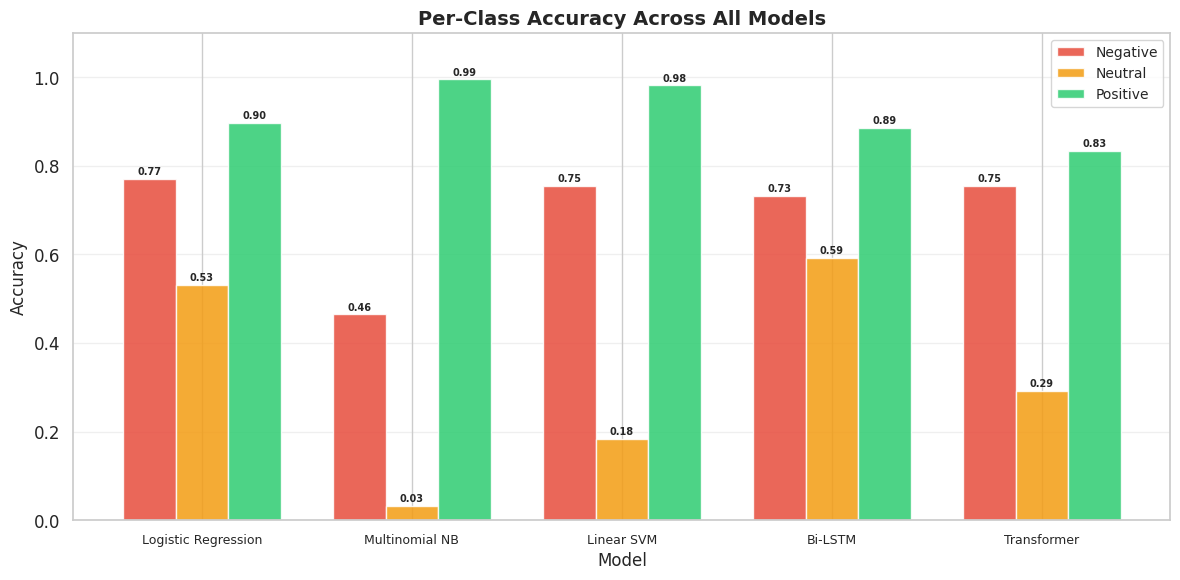


✓ Per-class accuracy chart saved to per_class_accuracy.png


In [45]:
# ============================================================================
# Per-Class Accuracy Breakdown
# ============================================================================

def per_class_accuracy(y_true, y_pred, class_names):
    """Compute accuracy for each class individually."""
    results = {}
    for i, name in enumerate(class_names):
        mask = y_true == i
        if mask.sum() > 0:
            results[name] = (y_pred[mask] == i).mean()
        else:
            results[name] = 0.0
    return results

# ── Compute per-class accuracy for all models ────────────────────────────
per_class_data = {}

# ML baselines
for name in baseline_evaluations:
    per_class_data[name] = per_class_accuracy(
        y_test_dl, baseline_evaluations[name]['y_pred'], target_names
    )

# DL models
for name in dl_evaluations:
    per_class_data[name] = per_class_accuracy(
        y_test_dl, dl_evaluations[name]['y_pred'], target_names
    )

# ── Display as table ─────────────────────────────────────────────────────
pc_rows = []
for model_name, class_accs in per_class_data.items():
    row = {'Model': model_name}
    row.update(class_accs)
    pc_rows.append(row)

pc_df = pd.DataFrame(pc_rows)
pc_display = pc_df.copy()
for col in target_names:
    pc_display[col] = pc_display[col].apply(lambda x: f'{x:.4f}')
print('=== Per-Class Accuracy (Test Set) ===\n')
print(pc_display.to_string(index=False))

# ── Grouped bar chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

models_list = pc_df['Model'].tolist()
x = np.arange(len(models_list))
width = 0.25
class_colors = ['#e74c3c', '#f39c12', '#2ecc71']

for i, (cls, color) in enumerate(zip(target_names, class_colors)):
    values = pc_df[cls].values
    bars = ax.bar(x + i * width, values, width,
                  label=cls, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy Across All Models', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models_list, fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Per-class accuracy chart saved to per_class_accuracy.png')

## Interpretability: Bi-LSTM Attention Heatmaps

The Bi-LSTM's self-attention mechanism assigns importance weights to each token. By visualising these weights, we can see **which words the model considers most important** for its sentiment prediction.

This is a key advantage over traditional ML (bag-of-words) — the model's reasoning is partially transparent and can be validated by human judgment.

We select representative examples:
- One **correctly classified** review per sentiment class
- One **misclassified** review to understand failure modes

=== Bi-LSTM Attention Visualisation ===


--- CORRECT Example (index 2154) ---
Review: poor chinese quality pure chinese garbage. sure, they work in as much as they plug into a headphone jack, but that is where the functionality ends. you expect sound from...


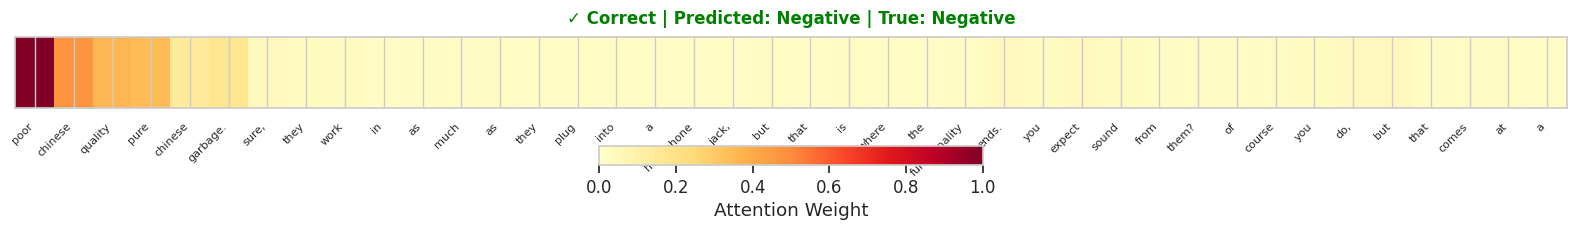


--- CORRECT Example (index 2576) ---
Review: sound great comfortable but they quit pairing with each other these sound excellent though they aren't as dynamic as other earbuds i have tried are a little light on bass....


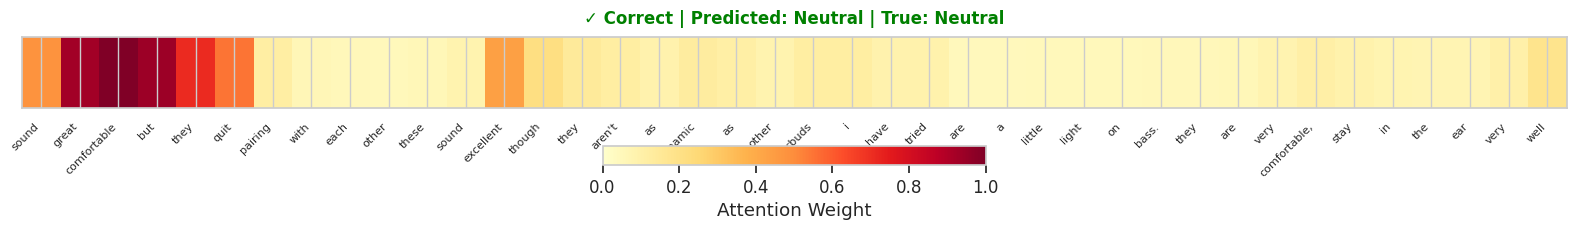


--- CORRECT Example (index 2369) ---
Review: very happy nice case, protects my <UNK> with a keyboard cover that protects <UNK> keyboard from dirt and debris, i wish i had that before <UNK> is colorful and seems...


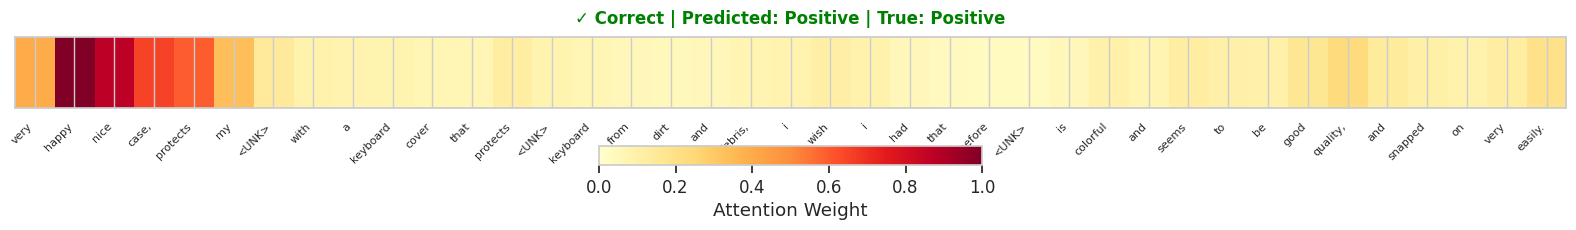


--- MISCLASSIFIED Example (index 2490) ---
Review: much better than usb dongle i had a usb unit and it was slow. i ordered this bluetooth and it sped up the operations, appreciably....


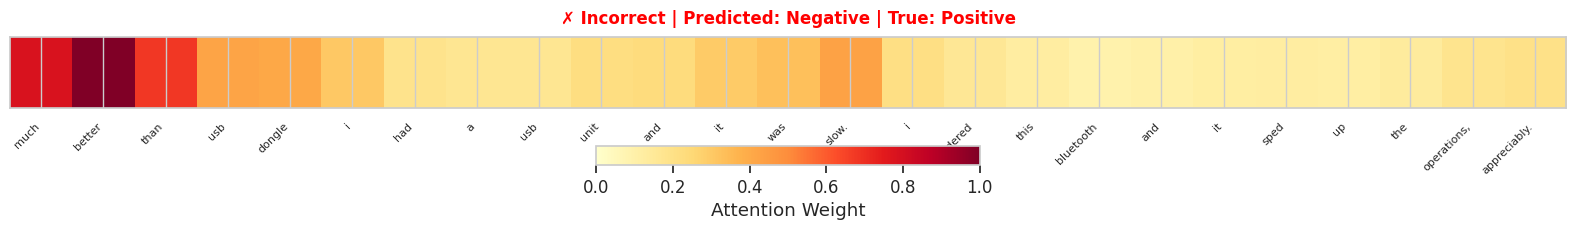

In [46]:
# ============================================================================
# Bi-LSTM Attention Visualisation
# ============================================================================

def decode_tokens(token_ids, vocab, length):
    """Convert token IDs back to words using vocabulary."""
    words = []
    for idx in token_ids[:length]:
        word = vocab.idx2word.get(int(idx), '<UNK>')
        if word != '<PAD>':
            words.append(word)
    return words


def plot_attention_heatmap(words, attn_weights, prediction, true_label,
                           class_names, max_words=40):
    """
    Plot attention weights as a horizontal heatmap over review tokens.

    Highlights which words the Bi-LSTM considers most important for
    its prediction — providing interpretability for stakeholders.

    Args:
        words: List of decoded word tokens.
        attn_weights: Attention weights for each token.
        prediction: Model's predicted class index.
        true_label: True class index.
        class_names: List of class names.
        max_words: Maximum words to display (truncate for readability).
    """
    # Truncate for readability
    words = words[:max_words]
    weights = attn_weights[:len(words)]

    # Normalise weights for colour intensity
    weights = weights / weights.max() if weights.max() > 0 else weights

    fig, ax = plt.subplots(figsize=(16, 2.5))

    # Create heatmap
    im = ax.imshow(weights.reshape(1, -1), cmap='YlOrRd', aspect='auto',
                   vmin=0, vmax=1)

    # Add word labels
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha='right', fontsize=8)
    ax.set_yticks([])

    # Title with prediction info
    pred_name = class_names[prediction]
    true_name = class_names[true_label]
    status = '✓ Correct' if prediction == true_label else '✗ Incorrect'
    colour = 'green' if prediction == true_label else 'red'

    ax.set_title(
        f'{status} | Predicted: {pred_name} | True: {true_name}',
        fontsize=12, fontweight='bold', color=colour, pad=10
    )

    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.3,
                 label='Attention Weight', shrink=0.5)
    plt.tight_layout()
    plt.show()


# ── Select representative examples ───────────────────────────────────────
print('=== Bi-LSTM Attention Visualisation ===\n')

preds = bilstm_results['preds']
labels = bilstm_results['labels']

# Find one correct example per class + one misclassified
examples = []
for cls in range(3):
    # Correct prediction
    correct_mask = (preds == cls) & (labels == cls)
    correct_indices = np.where(correct_mask)[0]
    if len(correct_indices) > 0:
        # Pick one with moderate length for readability
        idx = correct_indices[len(correct_indices) // 3]
        examples.append(('correct', idx))

# Find a misclassified example
wrong_mask = preds != labels
wrong_indices = np.where(wrong_mask)[0]
if len(wrong_indices) > 0:
    idx = wrong_indices[len(wrong_indices) // 3]
    examples.append(('misclassified', idx))

# ── Plot attention heatmaps ──────────────────────────────────────────────
for label, idx in examples:
    token_ids = bilstm_results['text_ids'][idx]
    length = int(bilstm_results['lengths'][idx])
    attn = bilstm_results['attn'][idx]

    words = decode_tokens(token_ids, vocab, length)
    attn_weights = attn[:length]

    print(f'\n--- {label.upper()} Example (index {idx}) ---')
    print(f'Review: {" ".join(words[:30])}...')

    plot_attention_heatmap(
        words, attn_weights,
        prediction=int(preds[idx]),
        true_label=int(labels[idx]),
        class_names=target_names
    )

---

## Summary
### Key Observations 

- **ML vs DL performance gap**: The comparison table quantifies whether DL's added complexity is justified
- **Neutral class**: Expected to be the hardest across all models — linguistic overlap with both Positive and Negative
- **Bi-LSTM vs Transformer**: The Bi-LSTM's stronger performance on small data illustrates the importance of inductive bias
- **Attention interpretability**: The heatmaps show the model "reasoning" — which words drive predictions — providing transparency that bag-of-words models cannot offer
- **ROC/AUC**: Per-class discriminative ability shows how well each model distinguishes each sentiment from the others
---


# Total Runtime

In [47]:
# ============================================================================
# Notebook Runtime Tracker — END
# ============================================================================
import time as _time

_notebook_end_time = _time.time()
_elapsed = _notebook_end_time - _notebook_start_time

_hours = int(_elapsed // 3600)
_minutes = int((_elapsed % 3600) // 60)
_seconds = int(_elapsed % 60)

print('=' * 60)
print('TOTAL NOTEBOOK RUNTIME')
print('=' * 60)
print(f'  Started:  {_time.strftime("%Y-%m-%d %H:%M:%S", _time.localtime(_notebook_start_time))}')
print(f'  Finished: {_time.strftime("%Y-%m-%d %H:%M:%S", _time.localtime(_notebook_end_time))}')
print(f'  Elapsed:  {_hours}h {_minutes}m {_seconds}s ({_elapsed:.1f} seconds total)')
print('=' * 60)


TOTAL NOTEBOOK RUNTIME
  Started:  2026-05-02 16:57:37
  Finished: 2026-05-02 17:08:45
  Elapsed:  0h 11m 8s (668.5 seconds total)
